## Performance Prediction & Composition via Stochastic Network Calculus (SNC)

This notebook implements the probabilistic end-to-end performance modeling methodology (PEGASUS) on a small synthetic
system, so that every step can be inspected and the ground truth is known. It is structured as follows:

1. **Synthetic system (Section 1):** the training data and the ground truth, a simulated queueing pipeline.
2. **Learning (Sections 2–5):** one Gaussian Process (GP) per service predicts the execution time of an item from the
   configuration.
3. **Node bounds (Section 6):** from the GP's Moment Generating Function (MGF), a bound on the latency (sojourn time) of
   one service at arrival rate $\lambda$ that is violated with probability at most $\varepsilon$: the execution-time bound
   as a baseline (6a), the SNC queueing bound (6b), the SNC bound with propagated arrival models (6c) , the martingale
   bound (6d) and the martingale bound with propagated service spacing (6e), checked on held-out configurations (6f).
4. **Composition (Section 7):** two compositions give an end-to-end bound that holds for any dependence between
   services: the union bound over the node bounds (7a) and the network service curve of classical SNC with Hölder's
   inequality (7b). Composition by independence (7c), the Deep GP models of the previous paper (7d) and a Fluxion-style
   composition of learned latency quantiles (7e) are baselines; 7f compares all of them at one configuration.
5. **Design space and depth (Sections 8–9):** the compositions across configurations and chain depths.

The ground truth is fed by Poisson or periodic arrivals (`arrival_process` in the first cell), and the bounds are checked
against simulated end-to-end latencies, not against execution times alone. The violation probability $\varepsilon$ is
`alpha` in the code. The helpers shared with `why_poisson_is_loose.ipynb` (arrival models, bounds, simulator) are in
`snc_bounds.py`, the GP model in `service_gp.py`, and all baselines in `baselines.py`.

In [1]:
# ==============================================================================
# Performance Prediction & Composition via SNC
# ==============================================================================

import matplotlib.pyplot as plt
import numpy as np
from IPython.display import Markdown, display
from scipy.stats import norm

from service_gp import execution_time_belief, train_gp_models
from snc_bounds import (martingale_node_bound, martingale_propagated_node_bound, martingale_propagated_node_bounds, network_service_bound, propagated_node_bounds, propagated_node_moments, quantile_with_lower_bound,
                        simulate_chain, snc_latency_bound)
from baselines import (advanced_training_rows, basic_training_rows, compute_snc_mgf_delay_bound, fluxion_training_rows,
                       independent_node_latencies, independent_snc_convolution, joint_gaussian_quantile, paired_independence_effect,
                       train_chain_dgp, train_fluxion_chain, union_bound_oracle)

# Set global seed for reproducibility
np.random.seed(35)

# Violation probability epsilon of every bound: a bound at alpha is a bound on the (1 - alpha) latency quantile
alpha = 0.05
z_score = norm.ppf(1 - alpha)

# Format dynamic percentile label (e.g., '99.99' or '95')
p_pct = (1 - alpha) * 100
p_str = f"{p_pct:.2f}".rstrip('0').rstrip('.')

# Workload and ground truth
arrival_rate = 4.0        # lambda: items per second offered to the pipeline
# arrival process of the items entering the pipeline
#   "poisson" : exponential gaps with mean 1/lambda (many unsynchronized devices)
#   "periodic": gaps of (1/lambda) * (1 + U(-arrival_jitter, arrival_jitter)) (one device or stream at a fixed rate)
arrival_process = "poisson"
arrival_jitter = 0.2      # relative half-width of the uniform jitter on periodic gaps, in [0, 1)
item_correlation = 0.7    # correlation of an item's execution-time noise across services (a large item is slow everywhere)
n_sim_items = 5000        # items per simulated run of the ground truth
workload = dict(process=arrival_process, rate=arrival_rate, jitter=arrival_jitter)   # passed to every bound and simulation
arrival_name = "Poisson" if arrival_process == "poisson" else f"periodic (±{arrival_jitter:.0%} jitter)"   # named in every conclusion
depths = [1, 2, 3, 5, 10, 20]   # chain depths of the depth study (Section 9); the DGP and Fluxion-style baselines are trained up to the deepest

# Belief and evaluation
confidence = 0.95        # the pessimistic mean of every bound lies above the true mean with this probability (6b)
coverage_check = dict(n_batches=10, confidence=0.95)   # confidence interval of a measured quantile (batch means), see 6f

# Formatting of conclusions that are rendered from the results
pct = lambda value: f"{value:.0%}"
ratio = lambda value: f"{value:.2f}×"


def span(values, fmt):
    # "between a and b", or just "a" if both round to the same text
    low, high = fmt(np.min(values)), fmt(np.max(values))
    return low if low == high else f"between {low} and {high}"

## 1. Synthetic System

A pipeline of three microservices ($s_1 \to s_2 \to s_3$), whose execution times depend on the configuration $x$ =
(CPU, quality, parallelism) of a service. The section is structured as follows:

- **1a. Training data:** single-service measurements of the execution time.
- **1b. Ground truth:** the pipeline as a queueing system, simulated item by item.

### 1a. Training Data

The arrival rate $\lambda$ (items/s) and the arrival process (`arrival_process`: Poisson or periodic) determine how many
items queue, above all at the first service. The training data below are single-service measurements of execution
time; the ground truth for latencies also includes queueing (Section 1b).

In [2]:
def true_demand(x, service_type):
    """Simulates latency demand d(x) = f(cpu, quality, parallelism)."""
    cpu, quality, parallelism = x[:, 0], x[:, 1], x[:, 2]
    if service_type == "type_A":
        return 0.010 + 0.040 / cpu + 0.030 * (quality ** 2.0)
    elif service_type == "type_B":
        return 0.012 + 0.035 / cpu + 0.025 * (quality ** 1.5)
    else:
        return 0.008 + 0.030 / cpu + 0.020 * (quality ** 1.8)

n_train = 50
X_train = np.column_stack([
    np.random.uniform(0.5, 2.0, n_train),  # CPU
    np.random.uniform(0.5, 2.0, n_train),  # Quality
    np.random.uniform(1.0, 4.0, n_train)  # Parallelism
])

service_names = ["s1", "s2", "s3"]
service_types = ["type_A", "type_B", "type_C"]
y_train_dict = {}

# Standard deviation of the execution-time noise per service (s)
noise_levels = {
    "s1": 0.0060,  # high variance
    "s2": 0.0010,  # low variance (stable)
    "s3": 0.0035   # medium variance
}

for s_name, s_type in zip(service_names, service_types):
    y_clean = true_demand(X_train, s_type)
    noise = np.random.normal(0, noise_levels[s_name], n_train)
    y_train_dict[s_name] = y_clean + noise

print("Training dataset successfully generated.")

Training dataset successfully generated.


### 1b. Ground Truth: the Pipeline as a Queueing System

Items arrive at rate $\lambda$, either as a Poisson process or periodically with uniform jitter (`arrival_process`).
Every service is one FIFO server; an item leaves $s_k$ and immediately enters $s_{k+1}$ (workload propagation). The
execution time of item $i$ at service $k$ is $d_k(x) + \sigma_k z_{ik}$, where the noise $z_{ik}$ is shared across
services with correlation `item_correlation`: a large request is slow at every service. The marginal execution time of
each service is exactly the one the training data was drawn from, so the GPs are not affected.

The latency (sojourn time) of an item at a service is its queueing wait plus its execution time. The ground-truth
$(1-\varepsilon)$ latency quantile of a configuration is estimated from `n_sim_items` simulated items.

A simpler ground truth, the sum of independent Gaussian execution times without any queue, is kept as a baseline in
Section 7c: it does not depend on $\lambda$, and its nodes are independent by construction.

In [3]:
# Ground truth: the chain simulator of snc_bounds with the mean execution times of true_demand.
# Vectorized over configurations: x_cfgs has one row per configuration.
def simulate_pipeline(x_cfgs, path_types, path_noise_levels, n_items, item_correlation, rng, workload):
    """Per-node latencies (configurations, items, nodes) and end-to-end latencies (configurations, items)."""
    x_cfgs = np.atleast_2d(x_cfgs)
    mean_execution = np.column_stack([true_demand(x_cfgs, s_type) for s_type in path_types])
    return simulate_chain(mean_execution, path_noise_levels, n_items=n_items, item_correlation=item_correlation, rng=rng, **workload)


def quantile_per_config(samples, level=1 - alpha):
    return np.quantile(samples, level, axis=1)


print("Ground-truth simulator ready.")

Ground-truth simulator ready.


## 2. Learning Stage (Gaussian Process Surrogate Models)

We train a GP for each service to capture execution time distributions, decomposing epistemic (model) and aleatoric (noise) uncertainties.

In [4]:
# ScaledGPRegressor (scikit-learn GP with feature scaling and the epistemic / aleatoric split) and train_gp_models
# are in service_gp.py.
gp_models = train_gp_models(X_train, y_train_dict, service_names)
print("Trained GP models for all microservices.")

Trained GP models for all microservices.


## 3. Visualization: Fitted GPs over CPU and Quality

The GP predictive distribution of every service as a surface over CPU and quality, with parallelism fixed: the GP mean
(solid surface), a $\pm 2\sigma$ envelope (blue wireframes), the true demand (red dashed wireframe), and the training
samples with their residuals to the GP mean.

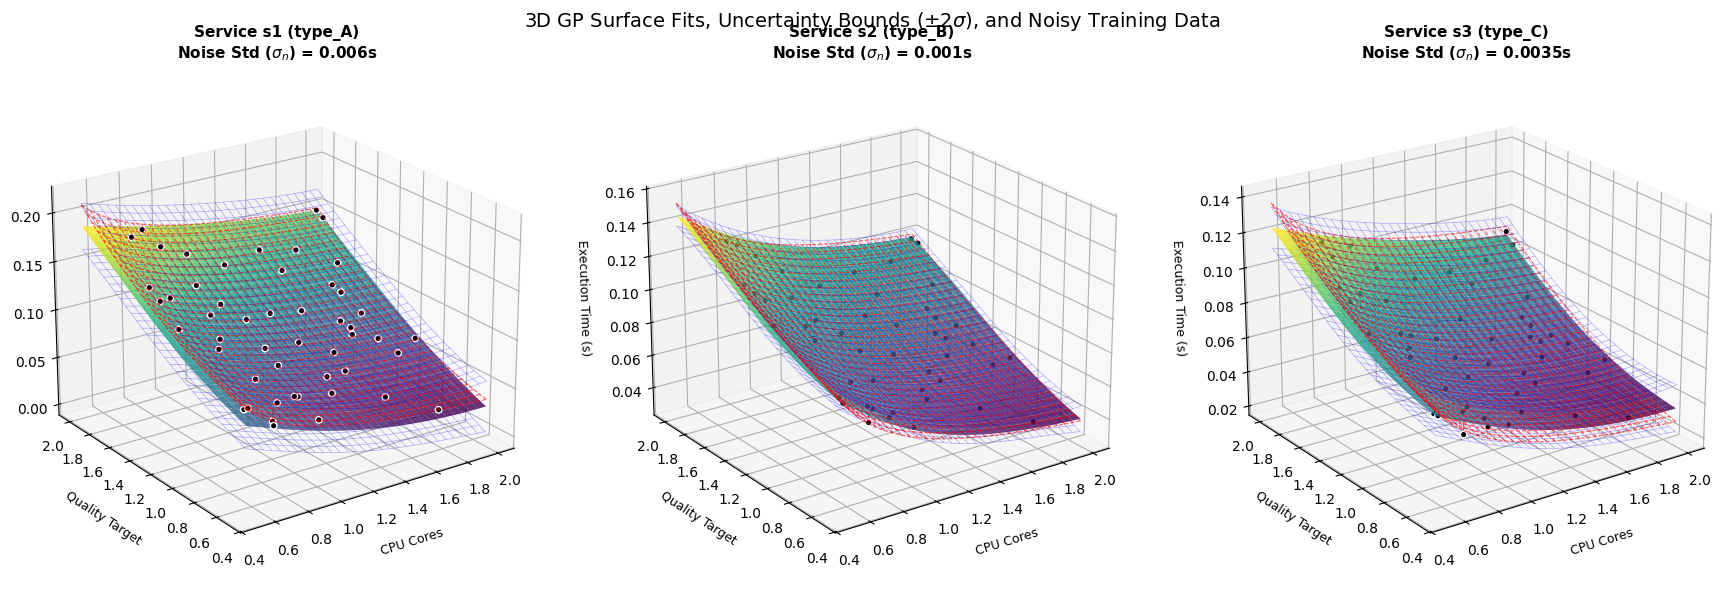

In [5]:
# Create 2D grid across both CPU (cores) and Quality
n_grid = 30
cpu_axis = np.linspace(0.5, 2.0, n_grid)
quality_axis = np.linspace(0.5, 2.0, n_grid)

CPU_grid, QUALITY_grid = np.meshgrid(cpu_axis, quality_axis)
PARALLELISM_grid = np.full_like(CPU_grid, 2.0)  # fixed parallelism

# Flatten grid for predictions
X_grid_3d = np.column_stack([
    CPU_grid.ravel(),
    QUALITY_grid.ravel(),
    PARALLELISM_grid.ravel()
])

fig = plt.figure(figsize=(18, 6), dpi=100)

for idx, (s_name, s_type) in enumerate(zip(service_names, service_types), 1):
    ax = fig.add_subplot(1, 3, idx, projection='3d')

    # Predict GP mean and standard deviation across 2D grid
    mu, std = gp_models[s_name].predict(X_grid_3d, return_std=True)
    mu_surface = mu.reshape(n_grid, n_grid)
    std_surface = std.reshape(n_grid, n_grid)

    # 1. Plot GP Predicted Mean Surface (Solid Mesh)
    surf_mean = ax.plot_surface(
        CPU_grid, QUALITY_grid, mu_surface,
        cmap='viridis', alpha=0.8, edgecolor='none', label=r"GP Mean $\mu(x)$"
    )

    # 2. Plot GP Uncertainty Envelope (+- 2 std) as transparent wireframes
    ax.plot_wireframe(
        CPU_grid, QUALITY_grid, mu_surface + 2 * std_surface,
        color='blue', linewidth=0.5, alpha=0.3, label=r"Upper Bound ($\mu + 2\sigma$)"
    )
    ax.plot_wireframe(
        CPU_grid, QUALITY_grid, mu_surface - 2 * std_surface,
        color='blue', linewidth=0.5, alpha=0.3, label=r"Lower Bound ($\mu - 2\sigma$)"
    )

    # 3. Plot True Demand (Red Dashed Wireframe)
    y_true_surface = true_demand(X_grid_3d, s_type).reshape(n_grid, n_grid)
    ax.plot_wireframe(
        CPU_grid, QUALITY_grid, y_true_surface,
        color='red', linewidth=0.8, linestyle='--', alpha=0.6, label=r"True Demand $f(x)$"
    )

    # 4. Scatter Training Samples with Vertical Drop Lines to see 3D position clearly
    x_train_cpu = X_train[:, 0]
    x_train_qual = X_train[:, 1]
    y_train_obs = y_train_dict[s_name]

    # Draw vertical stem lines connecting each point to the GP Mean
    for x_c, x_q, y_o in zip(x_train_cpu, x_train_qual, y_train_obs):
        # Predict mean at specific point to draw residual stem
        mu_pt = gp_models[s_name].predict(np.array([[x_c, x_q, 2.0]]))
        ax.plot([x_c, x_c], [x_q, x_q], [mu_pt[0], y_o], color='black', alpha=0.4, linewidth=0.8)

    # Scatter actual noisy observations
    ax.scatter(
        x_train_cpu, x_train_qual, y_train_obs,
        color='black', s=22, edgecolors='white', alpha=1.0, zorder=10, label="Observed Training Data"
    )

    # Aesthetics & Labels
    ax.set_title(f"Service {s_name} ({s_type})\nNoise Std ($\\sigma_n$) = {noise_levels[s_name]}s", fontsize=11, fontweight='bold')
    ax.set_xlabel("CPU Cores", fontsize=9, labelpad=8)
    ax.set_ylabel("Quality Target", fontsize=9, labelpad=8)
    ax.set_zlabel("Execution Time (s)", fontsize=9, labelpad=8)
    ax.view_init(elev=22, azim=-125)

plt.suptitle(r"3D GP Surface Fits, Uncertainty Bounds ($\pm 2\sigma$), and Noisy Training Data", fontsize=14, y=0.98)
plt.tight_layout()
plt.show()

## 4. Visualization: Coverage Analysis of the GP (Test Dataset)

We evaluate empirical coverage on a held-out test dataset to verify that the GP's predictive distribution holds at
the targeted violation probability $\varepsilon$ (`alpha` in the first cell).

This section checks step 1 only: whether a single new *execution time* falls below the GP's predictive quantile
$\mu + z\sigma$. It is not a check of the latency bound, which also includes queueing; that check is in Section 6f.
The test inputs are drawn from the training range.

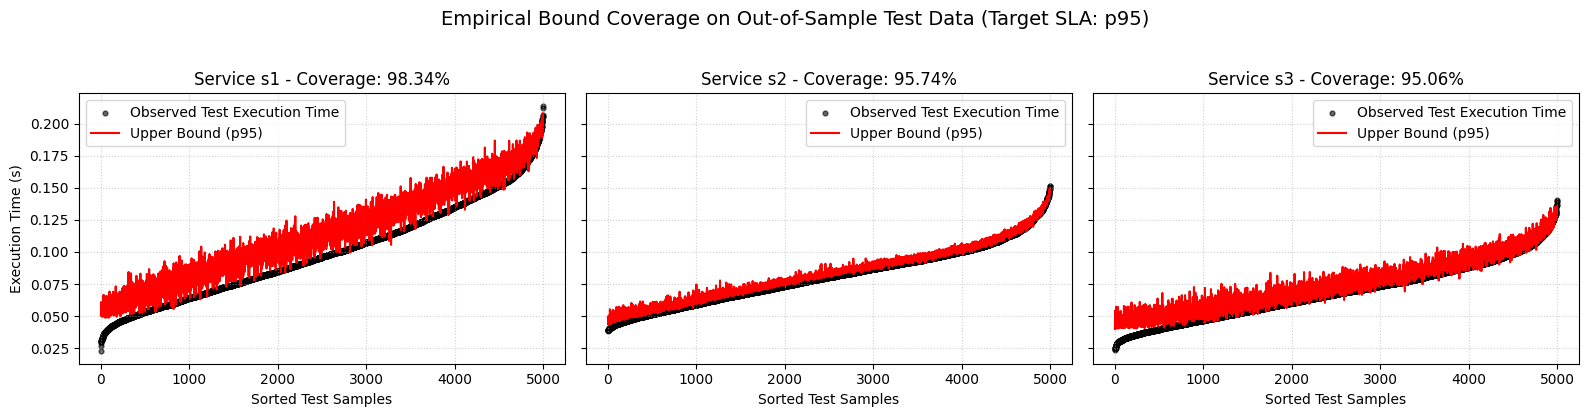

In [6]:
# Own random generator, so that the test data does not depend on which cells ran before
rng_test = np.random.default_rng(21)
n_test = 5000
X_test = np.column_stack([
    rng_test.uniform(0.5, 2.0, n_test),
    rng_test.uniform(0.5, 2.0, n_test),
    rng_test.uniform(1.0, 4.0, n_test)
])
# Test execution times per service, also used by Section 5
y_test_dict = {s_name: true_demand(X_test, s_type) + rng_test.normal(0, noise_levels[s_name], n_test)
               for s_name, s_type in zip(service_names, service_types)}

fig, axes = plt.subplots(1, 3, figsize=(16, 4), sharey=True)

for ax, s_name, s_type in zip(axes, service_names, service_types):
    y_true_test = y_test_dict[s_name]
    mu_test, std_test = gp_models[s_name].predict(X_test, return_std=True)

    upper_bound = mu_test + (z_score * std_test)
    coverage = np.mean(y_true_test <= upper_bound) * 100

    sort_idx = np.argsort(y_true_test)

    ax.scatter(range(n_test), y_true_test[sort_idx], color='black', alpha=0.6, s=12, label="Observed Test Execution Time")
    ax.plot(range(n_test), upper_bound[sort_idx], color='red', linewidth=1.5, label=f"Upper Bound (p{p_str})")

    ax.set_title(f"Service {s_name} - Coverage: {coverage:.2f}%")
    ax.set_xlabel("Sorted Test Samples")
    if s_name == "s1":
        ax.set_ylabel("Execution Time (s)")
    ax.legend()
    ax.grid(True, linestyle=":", alpha=0.6)

plt.suptitle(f"Empirical Bound Coverage on Out-of-Sample Test Data (Target SLA: p{p_str})", fontsize=14, y=1.03)
plt.tight_layout()
plt.show()

## 5. Visualization: GP Tightness Analysis

Tightness measures the residual margin $\text{Bound}(x) - \text{Observed}(x)$ of the GP's predictive quantile against single
execution times. Lower positive values reflect a tight, non-pessimistic interval. (For latency bounds, Sections 6f–9
report tightness as the ratio bound ÷ measured quantile, as in the testbed evaluation.)

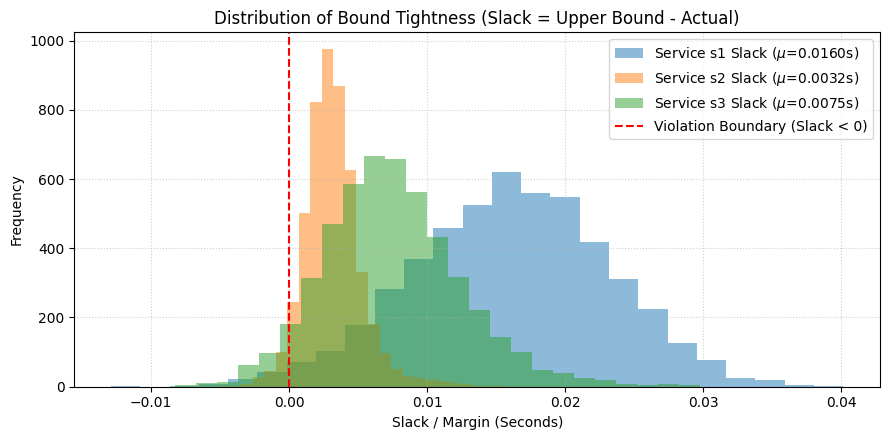

In [7]:
fig, ax = plt.subplots(figsize=(9, 4.5))

for s_name, s_type in zip(service_names, service_types):
    y_true_test = y_test_dict[s_name]   # the test execution times of Section 4
    mu_test, std_test = gp_models[s_name].predict(X_test, return_std=True)

    upper_bound = mu_test + z_score * std_test
    tightness = upper_bound - y_true_test

    ax.hist(tightness, bins=25, alpha=0.5, label=rf"Service {s_name} Slack ($\mu$={np.mean(tightness):.4f}s)")

ax.axvline(0, color='red', linestyle='--', linewidth=1.5, label="Violation Boundary (Slack < 0)")
ax.set_title("Distribution of Bound Tightness (Slack = Upper Bound - Actual)", fontsize=12)
ax.set_xlabel("Slack / Margin (Seconds)")
ax.set_ylabel("Frequency")
ax.legend()
ax.grid(True, linestyle=":", alpha=0.6)

plt.tight_layout()
plt.show()

## 6. Node Bounds: the Latency of One Service

A node bound is a latency $d$ of one service that is exceeded with probability at most $\varepsilon$. All node bounds start
from the GP's prediction of the execution time $X$: its mean $\mu(x)$, its variance $\sigma^2(x)$, and the closed-form
Moment Generating Function (MGF) $M_X(\theta) = \mathbb{E}[e^{\theta X}] = \exp\left(\theta \mu + \frac{\theta^2}{2}\sigma^2\right)$.
The section is structured as follows:

- **6a. Execution-time bound (baseline):** Chernoff's inequality on one execution time, without a queue.
- **6b. SNC queueing bound:** the latency at a FIFO server with renewal arrivals, from a union bound over queue lengths
  and Chernoff's inequality, with the GP's predictive distribution as the belief about the execution time.
- **6c. Propagated arrival models:** the SNC bound for a node that receives the departures of the node before it.
- **6d. Martingale bound:** a bound on the waiting time from an exponential martingale, without the Chernoff step.
- **6e. Martingale bound with propagated service spacing:** the martingale bound for a node that receives the
  departures of the node before it (6c and 6d combined).
- **6f. Node bounds on held-out configurations (RQ1):** coverage and tightness against simulated single services.

The cell below sets up the evaluation of 6f (held-out configurations and their simulated single-service latencies);
each subsection then computes its node bound directly after its explanation.

In [8]:
# Setup of the evaluation in 6f: held-out configurations, their simulated single-service latencies (ground truth), and
# the belief about the execution time (execution_time_belief in service_gp.py: the epistemic mean shift of 6b).
# Every subsection below adds its node bound to node_bounds.
rng_nodes = np.random.default_rng(7)
n_cfg_test = 100
X_cfg_test = np.column_stack([
    rng_nodes.uniform(0.5, 2.0, n_cfg_test),
    rng_nodes.uniform(0.5, 2.0, n_cfg_test),
    rng_nodes.uniform(1.0, 4.0, n_cfg_test)
])
measured_by_service, measured_low_by_service, beliefs, node_bounds = {}, {}, {}, {}
for s_name, s_type in zip(service_names, service_types):
    _, latency = simulate_pipeline(X_cfg_test, [s_type], [noise_levels[s_name]], n_sim_items, item_correlation, rng_nodes, workload)
    measured_by_service[s_name], measured_low_by_service[s_name] = quantile_with_lower_bound(latency, 1 - alpha, **coverage_check)
    beliefs[s_name] = execution_time_belief(gp_models[s_name], X_cfg_test, confidence)
    node_bounds[s_name] = {}
print("Setup of Section 6 ready.")

Setup of Section 6 ready.


### 6a. Execution-Time Bound (Baseline)

Chernoff's inequality $P(X \ge D) \le M_X(\theta)\,e^{-\theta D}$, optimized over $\theta$, gives
$D = \mu + \sigma\sqrt{2\ln(1/\varepsilon)}$. It ignores the arrival rate $\lambda$ and the queue, so it is not a bound on
latency; it is kept as the baseline "Chernoff only execution" (`compute_snc_mgf_delay_bound` in `baselines.py`).

In [9]:
# Execution-time bound (baseline; compute_snc_mgf_delay_bound in baselines.py)
for s_name in service_names:
    node_bounds[s_name]["Chernoff only execution (6a)"] = compute_snc_mgf_delay_bound(gp_models[s_name], X_cfg_test, alpha=alpha)[0]

### 6b. SNC Queueing Bound

An item's latency $W$ at a FIFO server is the largest backlog it finds:
$W = \max_{n \ge 0}\left(\sum_{i=0}^{n} X_i - \sum_{i=1}^{n} T_i\right)$, where the $X_i$ are the execution times of the item and the
$n$ items before it, and the $T_i$ are inter-arrival times. A union bound over $n$ and Chernoff's inequality for each
term give

$$P(W > d) \;\le\; e^{-\theta d}\,\frac{M_X(\theta)}{1 - \rho(\theta)}, \qquad \rho(\theta) = M_X(\theta)\,\mathbb{E}[e^{-\theta T}] < 1,$$

which holds for any i.i.d. inter-arrival times. For Poisson arrivals $\mathbb{E}[e^{-\theta T}] = \lambda / (\lambda + \theta)$;
for periodic arrivals with gaps $T = \frac{1}{\lambda}(1 + U)$, $U \sim \mathcal{U}(-j, j)$, it is
$\mathbb{E}[e^{-\theta T}] = e^{-\theta a}\,\frac{1 - e^{-\theta w}}{\theta w}$ with $a = (1 - j)/\lambda$ and $w = 2j/\lambda$
($e^{-\theta/\lambda}$ for $j = 0$). The latency bound at violation probability $\varepsilon$ is the best $\theta$:
$\;d(\varepsilon) = \min_\theta \frac{1}{\theta}\left[\ln M_X(\theta) - \ln(1 - \rho(\theta)) - \ln \varepsilon\right]$.
For $\lambda \to 0$, $\rho \to 0$ and this is exactly the execution-time bound of 6a, its special case of an empty queue.
If $\rho(\theta) \ge 1$ for every $\theta$ (the service is overloaded) there is no finite bound.

**Belief about the execution time (epistemic mean shift).** The GP's error about the mean execution time at a
configuration (its epistemic uncertainty $\sigma_{\text{ep}}^2(x)$) is shared by every item at that configuration: if the
GP underestimates the mean by 5 ms, every item is 5 ms slower, and in a busy period of $n$ items the work grows by
$n \times$ 5 ms. The scatter of individual items (aleatoric, $\sigma_{\text{al}}^2$) is independent from item to item and
partly averages out. Every bound therefore uses a pessimistic mean and only the aleatoric variance per item:
$\mu^+(x) = \mu(x) + z_c\,\sigma_{\text{ep}}(x)$, where $z_c$ is the standard-normal quantile at the confidence level $c$
(`confidence` in the first cell), so the true mean lies below $\mu^+$ with probability $c$ (`execution_time_belief` in
`service_gp.py`).

In [10]:
# SNC queueing bound (snc_latency_bound in snc_bounds.py)
for s_name in service_names:
    node_bounds[s_name]["SNC (6b)"] = snc_latency_bound(*beliefs[s_name], epsilon=alpha, **workload)

### 6c. Node Bound with Propagated Arrival Models

The SNC bound (6b) assumes that its node receives the *external* arrivals. That is true for the first
node only: node $k \ge 2$ receives the departures of node $k-1$. The propagated node bound bounds those departures instead
of reusing the external arrival process. It is composed with the union bound like the other node bounds (Section 7a)
(`propagated_node_bounds` in `snc_bounds.py`).

Let $A_n$ be the time between the arrivals of item $i-n$ and item $i$ at node $k$, i.e. between their departures from
node $k-1$. Write $X'$ for execution times and $W'$ for latencies at node $k-1$, and $A'_n$ for the same span at the
*input* of node $k-1$. Two lower bounds hold on every sample path:

1. **Service spacing:** node $k-1$ serves one item at a time, so $A_n \ge X'_{i-n+1} + \dots + X'_i$.
2. **Arrival spacing:** item $i$ leaves node $k-1$ no earlier than its arrival plus its execution time, and item
   $i-n$ leaves exactly at its arrival plus its latency, so $A_n \ge A'_n + X'_i - W'_{i-n}$.

Hence $\mathbb{E}[e^{-\theta A_n}] \le \min\big(M_{X'}(-\theta)^n,\; \mathbb{E}[e^{-\theta A'_n}]\,M_{X'}(-\theta)\,\mathbb{E}[e^{\theta W'}],\; \mathbb{E}[e^{-\theta T}]^n,\; 1\big)$.
The third term is the external arrival process, which the SNC bound (6b) assumes at every node; with it, the propagated
bound is never looser than the SNC bound. In the other two terms,
$\mathbb{E}[e^{\theta W'}]$ is the moment that node $k-1$'s own bound already computes. Wherever node $k-1$'s execution times space the items
(the terms with $M_{X'}(-\theta)$), node $k-1$ enters with its optimistic mean $\mu'^- = \mu' - z_c\,\sigma'_{\text{ep}}$, because a
faster node spaces items less; its latency moment keeps the pessimistic mean of 6b. Node $k$'s bound is the
union/Chernoff sum of Section 6b with this spacing in place of the external one:
$P(W > d) \le e^{-\theta d} \sum_n M_X(\theta)^{n+1}\,\mathbb{E}[e^{-\theta A_n}]$.

Bound 1 removes the double counting: a node behind a slower node almost never queues, and its bound now reflects
that. Bound 2 carries the external arrival rate along the chain; it is needed where a node is slower than the node
before it.

**Assumptions (beyond those of the SNC bound, which the third term uses):**
- A node's execution times are independent of the spacing of its arrivals. For bound 1, positive correlation between
  an item's execution times at consecutive nodes makes this conservative: the difference of two positively
  correlated Gaussians has a smaller variance than that of two independent ones.
- The latency of item $i-n$ at node $k-1$ is independent of the arrival spacing after it. This is exact directly
  behind the external source (renewal arrivals) and an assumption further down. The simulated coverage in Sections 7
  and 9 tests it.

A single service has no upstream node, so there the propagated bound equals the SNC bound of 6b; it is computed on
chains in Sections 7a and 9.

### 6d. Martingale Node Bound

With Poisson arrivals, the SNC bound (6b) is loose mainly because of its last step: a Chernoff bound with
one $\theta$, which pays $\ln(1/\varepsilon)/\theta$ and a factor $1/(1-\rho(\theta))$ and cannot use that most items don't wait.
With periodic arrivals, $\theta$ is not capped and both terms are small (see `why_poisson_is_loose.ipynb`). The martingale bound replaces that step. Every node assumes the external arrival process, exactly like the SNC bound.
It is composed with the union bound like the other node bounds (Section 7a) (`martingale_node_bound` in
`snc_bounds.py`).

Write $Q$ for the waiting time of an item at a node (latency minus its own execution time $X$), $T$ for the gap
between arrivals, and $\theta^*$ for the decay rate of the waiting-time tail, the largest $\theta$ with
$\rho(\theta) = M_X(\theta)\,\mathbb{E}[e^{-\theta T}] \le 1$.

1. **Waiting time, any renewal arrivals (Kingman's martingale bound):** $e^{\theta^* (X_1 - T_1 + \dots + X_n - T_n)}$ is a
   martingale over $n$, which gives $P(Q > w) \le e^{-\theta^* w}$. Unlike Section 6b there is no sum over $n$ and no
   $1/(1-\rho)$ factor.
2. **Waiting time, Poisson arrivals (refinement):** by Pollaczek–Khinchine, $Q$ is 0 with probability $1-\rho$ and
   otherwise a sum of residual execution times. Splitting off the first of them and applying step 1 to the rest gives
   $P(Q > w) \le \lambda \int_0^\infty P(X > x)\,\min\big(1, e^{-\theta^*(w - x)}\big)\,dx$, which is at most $\rho$ at
   $w = 0$: the bound now starts at the share of items that wait, not at 1.
3. **Latency:** $Q$ depends only on earlier items, so it is independent of the item's own $X$, and
   $P(Q + X > d) = \mathbb{E}_X\big[P(Q > d - X)\big]$ is computed directly (no second Chernoff step). The expectation is
   evaluated on equal-probability bins of $X$ at each bin's upper edge, with the last bin counted as a violation, so
   the discretization can only make the bound larger.

$\theta^*$ is taken from the same $\theta$ grid as Section 6b, as the largest grid value below the first crossing of
$\rho(\theta) = 1$; any $\theta \le \theta^*$ keeps both bounds valid. $X$ is the same belief as for the SNC bound
(the epistemic mean shift of 6b).

**Assumptions:** the same as the SNC bound (every node sees the external arrival process), plus renewal arrivals for step 1
and Poisson arrivals for step 2. For periodic arrivals, only step 1 is used.

In [11]:
# Martingale bound (martingale_node_bound in snc_bounds.py)
for s_name in service_names:
    node_bounds[s_name]["martingale (6d)"] = martingale_node_bound(*beliefs[s_name], epsilon=alpha, **workload)

### 6e. Martingale Bound with Propagated Service Spacing

The martingale bound of 6d assumes the external arrival process at every node. A node $k \ge 2$, however, receives the
departures of node $k-1$, which cannot be closer together than node $k-1$'s execution times (bound 1 of 6c). The waiting
time at node $k$ is then at most the maximum of a random walk with increments $X_{k,j} - X'_{j+1}$: an execution time at
node $k$ minus one at node $k-1$. For Gaussian execution times, Kingman's martingale bound (6d, step 1) applies to this walk
with the decay rate $\theta_s = 2(\mu'^- - \mu^+)/(\sigma^2 + \sigma'^2)$, which is large when node $k-1$ is slower. Here
$\mu^+$ is the pessimistic mean of node $k$ (6b), $\mu'^- = \mu' - z_c\,\sigma'_{\text{ep}}$ the optimistic mean of node $k-1$
(a faster node $k-1$ spaces items less), and $\sigma^2, \sigma'^2$ the aleatoric variances. Per node, the bound takes the
smaller of the two waiting-time tails, $\min\big(P_{6d}(Q > w),\, e^{-\theta_s w}\big)$, and adds the own execution time as in
6d (`martingale_propagated_node_bound` in `snc_bounds.py`). It is composed with the union bound (Section 7a).

**Assumptions beyond those of 6d:** consecutive increments share an item but are treated as independent, and an item's
own execution time is treated as independent of its wait (a slow item arrives later and waits less). With positively
correlated execution times of an item, both make the bound conservative; the simulated coverage in Sections 7 and 9 tests
them. A single service has no node before it, so in 6f the bound equals the martingale bound of 6d.

### 6f. Node Bounds on Held-Out Configurations (RQ1)

For random test configurations, we simulate each service alone as a queue at rate $\lambda$ and compare its measured
$(1-\varepsilon)$ latency quantile with each node bound. *Tightness* is the median of bound ÷ measured quantile. *Coverage* is the share of configurations
that a bound does not miss, where a configuration counts as missed only if the simulation shows that the bound lies below
the true quantile: below the lower edge of the confidence interval of the measured quantile (`coverage_check` in the first
cell; batch means over consecutive blocks of items, `quantile_with_lower_bound` in `snc_bounds.py`). A single simulated
quantile scatters, most at high load, so without the interval a tight bound would be counted as missed by chance. A valid
bound can still miss where the GP's error about the mean exceeds its confidence band.

The execution-time bound (6a) is included to show what it misses. The propagated bound (6c) is
identical to the SNC bound for a single service, which has no upstream node.

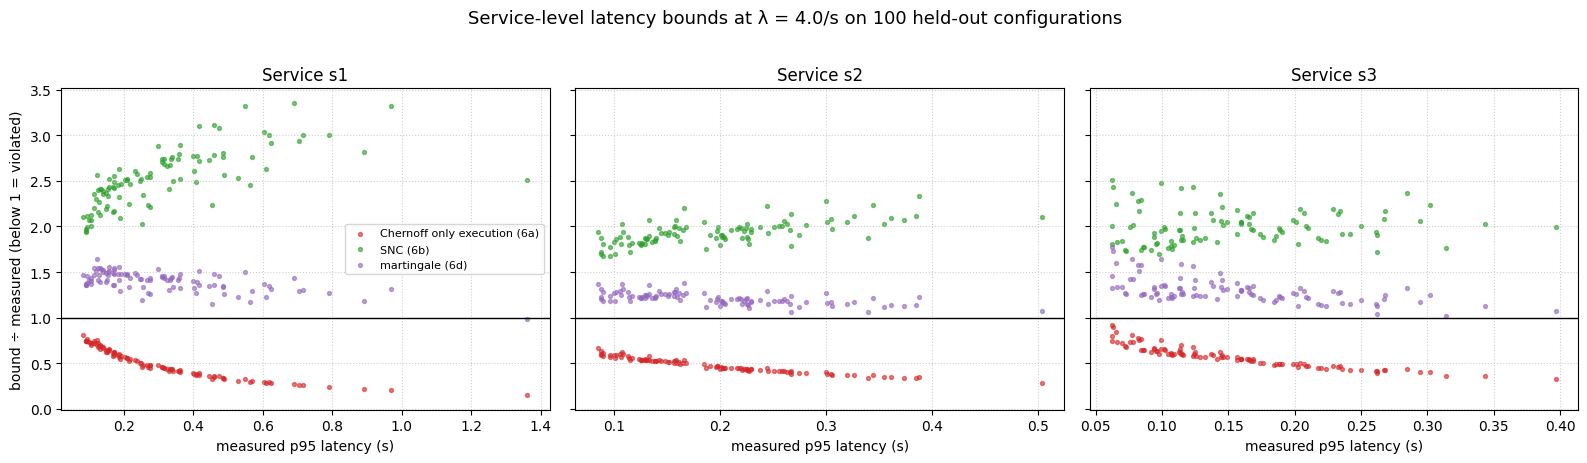

service  bound                               coverage  tightness
s1       Chernoff only execution (6a)            0.0%      0.49x
s1       SNC (6b)                              100.0%      2.51x
s1       martingale (6d)                       100.0%      1.42x
s2       Chernoff only execution (6a)            0.0%      0.47x
s2       SNC (6b)                              100.0%      1.93x
s2       martingale (6d)                       100.0%      1.21x
s3       Chernoff only execution (6a)            0.0%      0.57x
s3       SNC (6b)                              100.0%      1.98x
s3       martingale (6d)                       100.0%      1.27x


In [12]:
# Comparison of the node bounds of 6a, 6b and 6d against the simulated single-service latencies of the setup
bound_names = ["Chernoff only execution (6a)", "SNC (6b)", "martingale (6d)"]   # order of the subsections
single_node_results = {}
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5), sharey=True)
for ax, s_name in zip(axes, service_names):
    measured = measured_by_service[s_name]
    for name, color in zip(bound_names, ["tab:red", "tab:green", "tab:purple"]):
        bound = node_bounds[s_name][name]
        single_node_results[(s_name, name)] = {"coverage": np.mean(bound >= measured_low_by_service[s_name]), "tightness": np.median(bound / measured)}
        ax.scatter(measured, bound / measured, s=8, alpha=0.6, color=color, label=name)
    ax.axhline(1.0, color="black", linewidth=1)
    ax.set_title(f"Service {s_name}")
    ax.set_xlabel(f"measured p{p_str} latency (s)")
    ax.grid(True, linestyle=":", alpha=0.6)
axes[0].set_ylabel("bound ÷ measured (below 1 = violated)")
axes[0].legend(fontsize=8)
plt.suptitle(f"Service-level latency bounds at λ = {arrival_rate}/s on {n_cfg_test} held-out configurations", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print(f"{'service':<8} {'bound':<34} {'coverage':>9} {'tightness':>10}")
for (s_name, name), result in single_node_results.items():
    print(f"{s_name:<8} {name:<34} {result['coverage']:>9.1%} {result['tightness']:>9.2f}x")

In [13]:
across = lambda name, key: [single_node_results[(s_name, name)][key] for s_name in service_names]
misses = [f"{name} at {s_name} (covers {pct(single_node_results[(s_name, name)]['coverage'])})"
          for name in ("SNC (6b)", "martingale (6d)") for s_name in service_names if single_node_results[(s_name, name)]["coverage"] < 1]
display(Markdown(
    f"**What this shows** ({arrival_name} arrivals, λ = {arrival_rate:g}/s).\n"
    f"- **The execution-time bound (6a) is not a latency bound.** It covers {span(across('Chernoff only execution (6a)', 'coverage'), pct)} "
    "of the configurations per service, because it leaves out the queue.\n"
    f"- **The SNC queueing bound (6b)** covers {span(across('SNC (6b)', 'coverage'), pct)} of the configurations with tightness "
    f"{span(across('SNC (6b)', 'tightness'), ratio)}.\n"
    f"- **The martingale bound (6d)** covers {span(across('martingale (6d)', 'coverage'), pct)} of the configurations with tightness "
    f"{span(across('martingale (6d)', 'tightness'), ratio)}.\n"
    + ("- **Misses:** a configuration counts as missed only if the simulation shows, at "
       f"{pct(coverage_check['confidence'])} confidence, that the bound lies below the true p{p_str}. A valid bound can "
       "still miss where the GP's error about the mean exceeds its confidence band: " + "; ".join(misses) + ".\n"
       if misses else "- **No misses:** both latency bounds cover every configuration of every service.\n")))

**What this shows** (Poisson arrivals, λ = 4/s).
- **The execution-time bound (6a) is not a latency bound.** It covers 0% of the configurations per service, because it leaves out the queue.
- **The SNC queueing bound (6b)** covers 100% of the configurations with tightness between 1.93× and 2.51×.
- **The martingale bound (6d)** covers 100% of the configurations with tightness between 1.21× and 1.42×.
- **No misses:** both latency bounds cover every configuration of every service.


## 7. Composition & End-to-End Performance Analysis

A composition turns the node beliefs of a chain into a bound on its end-to-end latency. Two compositions give a guarantee
that holds for any dependence between the services (7a, 7b); the baselines either assume independence (7c) or have no
tail bound (7d, 7e). The section is structured as follows:

- **7a. Union bound:** sums the node bounds of Section 6 (SNC, propagated SNC, martingale, propagated martingale), each
  at violation probability $\varepsilon / K$.
- **7b. Network service curve:** the classical SNC composition: one bound from the concatenated service of all nodes,
  made valid for dependent nodes by Hölder's inequality.
- **7c. Composition by independence (baseline):** combining the node distributions or MGFs directly, valid only for
  independent services.
- **7d. Deep GP baselines:** the composition of the previous paper, trained without (DGP Basic) and with (DGP Advanced)
  queueing.
- **7e. Fluxion-style composition (baseline):** one GP per service and latency quantile, which receives the predicted
  latency quantiles of the service before it (Liang et al., NSDI 2023).
- **7f. Reference configuration:** every composition and baseline for one configuration, next to the simulated ground
  truth.

The cell below sets up the reference configuration (configuration, node beliefs, simulated ground truth); each
subsection then computes its compositions directly after its explanation, and 7f brings them together. Sections 8
and 9 apply the compositions across configurations and chain depths.

The *reference configuration* (`x_pipeline_cfg` in the setup cell) is one arbitrary operating point inside the training
range, used wherever a single configuration is shown. It is not an optimum or a typical setting.

In [14]:
# Setup of Section 7: the reference configuration, the node beliefs and bounds of its three services, and the ground
# truth, the simulated queueing pipeline (Section 1b) at this configuration.
x_pipeline_cfg = np.array([[1.0, 1.0, 2.0]])  # [CPU, Quality, Parallelism]
n_nodes = len(service_names)

# ------------------------------------------------------------------------------
# A. Node-level bounds
# ------------------------------------------------------------------------------
node_mus = []
node_stds = []
node_beliefs = []  # (pessimistic mean, aleatoric variance): the epistemic mean shift of 6b

print("\n=== Individual Node Performance Guarantees ===")
for s_name in service_names:
    model = gp_models[s_name]

    # Predict mean and standard deviation
    mu, std = model.predict(x_pipeline_cfg, return_std=True)

    # baseline: bound on the execution time only (no queue)
    delay, _, _, _ = compute_snc_mgf_delay_bound(model, x_pipeline_cfg, alpha=alpha)

    # SNC latency bounds with queueing, at the full budget epsilon and at the union-bound share epsilon / K
    belief = execution_time_belief(model, x_pipeline_cfg, confidence)
    latency_full = snc_latency_bound(*belief, epsilon=alpha, **workload)[0]
    latency_share = snc_latency_bound(*belief, epsilon=alpha / n_nodes, **workload)[0]

    node_mus.append(mu[0])
    node_stds.append(std[0])
    node_beliefs.append(belief)

    print(
        f"Service {s_name:2s} | "
        f"Pred exec time = {mu[0]:.4f}s (std = {std[0]:.4f}) | "
        f"exec-time bound = {delay[0]:.4f}s | "
        f"SNC latency bound at ε = {latency_full:.4f}s, at ε/K = {latency_share:.4f}s"
    )

# Ground truth: the queueing pipeline (Section 1b)
rng_reference = np.random.default_rng(42)
reference_node_latencies, reference_latencies = simulate_pipeline(
    np.repeat(x_pipeline_cfg, 20, axis=0), service_types, [noise_levels[s] for s in service_names],
    n_sim_items, item_correlation, rng_reference, workload)
oracle_queueing_p_latency = np.quantile(reference_latencies, 1 - alpha)


=== Individual Node Performance Guarantees ===
Service s1 | Pred exec time = 0.0808s (std = 0.0100) | exec-time bound = 0.1053s | SNC latency bound at ε = 0.4171s, at ε/K = 0.4854s
Service s2 | Pred exec time = 0.0723s (std = 0.0016) | exec-time bound = 0.0763s | SNC latency bound at ε = 0.2783s, at ε/K = 0.3239s
Service s3 | Pred exec time = 0.0587s (std = 0.0045) | exec-time bound = 0.0696s | SNC latency bound at ε = 0.2190s, at ε/K = 0.2548s


### 7a. Union Bound

A request violates the end-to-end bound $\sum_k d_k$ only if it violates at least one node bound $d_k$. So if every node
bound is computed at $\varepsilon / K$ for a path of $K$ nodes,

$$P\Big(\sum_k W_k > \sum_k d_k(\varepsilon / K)\Big) \;\le\; \sum_k P\big(W_k > d_k(\varepsilon / K)\big) \;\le\; \varepsilon,$$

whatever the dependence between the services. For a DAG, the budget is split over all nodes and the bound is the
longest path. Applied to the node bounds of Sections 6b–6e, the union bound gives the four strategies with a guarantee:
**union bound, SNC nodes**; **union bound, propagated SNC nodes**; **union bound, martingale nodes**; **union bound,
propagated martingale nodes**. The union bound composes node *bounds*; the network service curve (7b) composes the
nodes' service instead.

In [15]:
# Union bound (every node at epsilon / K) over the SNC (6b), propagated SNC (6c), martingale (6d) and propagated martingale (6e)
# node bounds; 6e needs the optimistic mean of every node (the spacing it gives the next node)
node_lower_means = [execution_time_belief(gp_models[s_name], x_pipeline_cfg, 1 - confidence)[0] for s_name in service_names]
union_snc_bound = sum(snc_latency_bound(*belief, epsilon=alpha / n_nodes, **workload)[0] for belief in node_beliefs)
propagated_bound = propagated_node_bounds(node_beliefs, epsilon=alpha / n_nodes, path_lower_means=node_lower_means, **workload).sum()
martingale_bound = sum(martingale_node_bound(*belief, epsilon=alpha / n_nodes, **workload)[0] for belief in node_beliefs)
propagated_martingale_bound = martingale_propagated_node_bounds(node_beliefs, node_lower_means, epsilon=alpha / n_nodes, **workload).sum()

### 7b. Network Service Curve with Hölder's Inequality

The union bound (7a) composes *node bounds*: every node gets its own share $\varepsilon / K$ of the violation probability
and its own $\theta$, and the end-to-end bound is the sum of the node bounds. Classical SNC composes the *service* of the
nodes instead: the service processes of the $K$ nodes are concatenated into one network service process, and a single
delay bound is computed from it and the external arrival envelope (Fidler, IWQoS 2006; Ciucu, Burchard & Liebeherr,
IEEE Trans. Inf. Theory 2006). This subsection derives that bound for the chain in the per-item (max-plus) form of 6b and
makes it valid for dependent nodes with Hölder's inequality; like the union bound (7a), it is a guarantee for any
dependence between the services.

**Arrival and service envelopes in 6b.** The bound of 6b already contains both SNC envelopes, written per item in the MGF
domain:
- the *arrival envelope* $\mathbb{E}[e^{-\theta A_n}] = \mathbb{E}[e^{-\theta T}]^n$, where $A_n$ is the time (s) spanned by $n$
  consecutive external inter-arrival gaps $T$ (s); it bounds how closely $n$ items can follow each other;
- the *service envelope* $\mathbb{E}[e^{\theta S}] = M_X(\theta)^{n+1}$, where $S$ is the work (s) of $n+1$ items at the
  node, the sum of their execution times;
- the *delay bound* is the union bound over the backlog $n$ that pairs the two envelopes (the sum in 6b).

**End-to-end latency of the chain.** Let $X^{(k)}_m$ be the execution time (s) of item $m$ at node $k$, and $D^{(k)}_m$ the time
it leaves node $k$. A FIFO node starts an item once the item has left the node before and the previous item has left
this node: $D^{(k)}_i = \max\big(D^{(k-1)}_i, D^{(k)}_{i-1}\big) + X^{(k)}_i$, with $D^{(0)}_i$ the external arrival of item $i$.
Unrolling this recursion gives the end-to-end latency of item $i$:
$$W_{\text{e2e}} = \max_{n \ge 0}\Big(\max_{n_1 + \dots + n_K = n}\ \sum_{k=1}^{K} S_k \;-\; A_n\Big).$$
Here $n$ is the number of items before item $i$ that still delay it, and the inner maximum runs over the ways to split
them over the nodes: at node $k$, item $i$ waits behind a busy period of $n_k + 1$ consecutive items whose total
execution time at node $k$ is $S_k$. Each split is a path through the (item, node) grid that steps either to the next
item or to the next node. The inner maximum is the max-plus convolution of the node service processes, the *network
service process*, and $A_n$ enters only once for the whole chain.

**Bound.** A union bound over $n$ and over the splits, and Chernoff's inequality for each term give
$$P(W_{\text{e2e}} > d) \;\le\; e^{-\theta d} \sum_{n_1, \dots, n_K \ge 0} \mathbb{E}\Big[\prod_{k} e^{\theta S_k}\Big]\, \mathbb{E}[e^{-\theta T}]^{\,n_1 + \dots + n_K}.$$
The expectation of the product is where dependence between the nodes enters: an item that is slow at $s_1$ is also slow
at $s_2$ (`item_correlation` in 1b), and the item at a turn of the path is counted at two nodes. **Hölder's inequality**
bounds it for any dependence: $\mathbb{E}[\prod_k e^{\theta S_k}] \le \prod_k \mathbb{E}[e^{p_k \theta S_k}]^{1/p_k}$ for exponents
$p_k \ge 1$ with $\sum_k 1/p_k = 1$ (their choice follows below). Within a node the items are independent given the
pessimistic mean $\mu^+$ (as in 6b), so $\mathbb{E}[e^{p\theta S_k}] = M_{X_k}(p\theta)^{n_k+1}$. For the Gaussian belief,
$M_X(p\theta)^{1/p} = \exp\big(\theta\mu^+ + \tfrac{p}{2}\theta^2\sigma_{\text{al}}^2\big)$: Hölder's inequality costs exactly a
$p$-fold aleatoric variance. Write $\tilde M_k(\theta)$ for this inflated MGF of node $k$ and
$\tilde\rho_k(\theta) = \tilde M_k(\theta)\,\mathbb{E}[e^{-\theta T}]$. The sum over the $n_k$ then factorizes into one geometric
series per node:
$$P(W_{\text{e2e}} > d) \;\le\; e^{-\theta d} \prod_{k=1}^{K} \frac{\tilde M_k(\theta)}{1 - \tilde\rho_k(\theta)}, \qquad
d(\varepsilon) = \min_\theta \frac{1}{\theta}\Big[\sum_{k} \ln\frac{\tilde M_k(\theta)}{1 - \tilde\rho_k(\theta)} - \ln\varepsilon\Big].$$
If $\tilde\rho_k(\theta) \ge 1$ for some node at every $\theta$, there is no finite bound.

**Choice of the Hölder exponents.** Any exponents with $\sum_k 1/p_k = 1$ give a valid bound, so they can be chosen
separately for every configuration and every $\theta$. The simplest choice is $p_k = K$ for every node; for $K = 3$ nodes,
every aleatoric standard deviation then grows by $\sqrt{3} \approx 1.7$. That choice inflates nodes with a small variance or
far from saturation as much as the critical ones. Minimizing the sum of the node log moments over the shares
$q_k = 1/p_k$ (with $\sum_k q_k = 1$) is a convex problem, and its optimum has
$q_k \propto \sigma_{\text{al},k} / \sqrt{1 - \tilde\rho_k(\theta)}$: a node with a large variance or close to saturation gets a large
share, i.e. a small inflation. The bound uses these tuned exponents (a damped fixed-point iteration, as $\tilde\rho_k$
depends on $p_k$) and keeps $p_k = K$ wherever that gives the smaller moment.

**Compared with the union bound and with 7c.** Every factor of the product is the node latency moment of 6b, with the
aleatoric variance multiplied by $p_k$. The union bound with SNC nodes (6b, 7a) sums $K$ node bounds
$\frac{1}{\theta_k}\big[\ln(\text{moment}_k) - \ln(\varepsilon / K)\big]$, each with its own $\theta_k$. The network bound pays the
$-\ln\varepsilon$ term only once for the whole chain (SNC's "pay bursts only once"), but it has to use one $\theta$ for all
nodes and inflates every aleatoric variance by its Hölder exponent. Which
effect wins depends on how much of a node's latency comes from its aleatoric variance; 7f and Section 9 compare them.
With $p_k = 1$ for every node, which is valid only for independent nodes, the formula is exactly the independent SNC
convolution of 7c: that baseline *is* the network service curve under independence.

**Assumptions:** FIFO nodes in tandem with unlimited queues; execution times independent from item to item within a
node, given the pessimistic mean (as in 6b); renewal arrivals, independent of the execution times; *any* dependence
between the nodes. Under these assumptions the bound is a guarantee at the same confidence level $c$ as the union
bound (7a). It uses the external arrival process only at the entrance of the chain, so the propagated arrival models of
6c have no counterpart here (`network_service_bound` in `snc_bounds.py`).

In [16]:
# Network service curve with tuned Hölder exponents (network_service_bound in snc_bounds.py)
network_bound = network_service_bound(node_beliefs, epsilon=alpha, **workload)[0]

### 7c. Composition by Independence (Baseline)

If the services were independent, their node distributions could be combined directly. Two baselines do this:

- **Joint Gaussian quantile:** the $(1-\varepsilon)$ quantile of the sum of independent Gaussian execution times,
  $\sum_k \mu_k + z_{1-\varepsilon}\sqrt{\sum_k \sigma_k^2}$. It has no queue.
- **Independent SNC convolution:** multiplies the node latency MGFs of 6b and optimizes one $\theta$. It includes the queue
  but is only valid for independent nodes; it is the network service curve of 7b with all Hölder exponents $p_k = 1$.

In this pipeline the nodes are not independent: an item that is large at $s_1$ is large at $s_2$ and $s_3$, and queues
propagate downstream. The cell below also checks the independence assumption directly: it removes the dependence between
the simulated node latencies and compares the resulting quantile with the real one, as a paired test on the same simulated items (`paired_independence_effect`
in `baselines.py`): most of the simulation noise affects both quantiles alike and cancels in their difference.

*Why SNC and not the joint Gaussian?* If execution times were Gaussian and independent, the joint Gaussian quantile would
be exact and any Chernoff bound would be looser: it adds $\sqrt{2\ln(1/\varepsilon)}$ standard deviations to the mean where
the Gaussian quantile adds $z_{1-\varepsilon}$ (for example 2.45 vs 1.64 at $\varepsilon = 0.05$). SNC earns its place because it (1) bounds queueing latency from the MGF, which has no closed-form
quantile, and (2) composes without assuming independence, with the union bound (7a) or the network service curve (7b).

In [17]:
# Composition by independence (baselines.py): joint Gaussian quantile of the execution times (no queue) and the
# independent SNC convolution (with queueing); neither is a guarantee
joint_gaussian_bound = joint_gaussian_quantile(node_mus, node_stds, z_score)
independent_bound = independent_snc_convolution(node_beliefs, alpha, **workload)[0]

# Is independence a safe assumption? Remove the dependence between the simulated node latencies and compare the quantile.
independent_latencies = independent_node_latencies(reference_node_latencies, rng_reference)
oracle_independent_p_latency = np.quantile(independent_latencies, 1 - alpha)
# Paired test on the same items; the replications of the reference configuration are pooled into one long series, and the
# test draws from its own random generator so that no other result changes
independence_shift, independence_upper = paired_independence_effect(reference_node_latencies.reshape(1, -1, n_nodes), 1 - alpha,
                                                                    np.random.default_rng(5), **coverage_check)

### 7d. Deep GP Baselines: DGP Basic and DGP Advanced

The previous version of this work (`rejected_paper.pdf`, Section 3.2) composed services with a Deep Gaussian Process
(DGP): one GP per service, where each GP receives the output of the GP before it as an additional input, trained service
by service, and evaluated by pushing Monte Carlo samples through the chain. Two versions of it are compared here as
baselines; their implementation is in `baselines.py` (part 3). In both, $L_k$ is the cumulative latency of an item from
entering the chain until it leaves the $k$-th service (s), and layer $k$ is a variational GP with inputs ($x$, $L_{k-1}$)
and output $L_k$.

- **DGP Basic** is the paper's model with latency in place of throughput. Its training rows are built from the
  single-service training data of Section 1 without any queue: $L_k = L_{k-1} + y_k$ (a service that appears again in the
  chain uses its rows in shuffled order, as in the paper).
- **DGP Advanced** is the same model trained on traced chain runs that include queueing: for every item, the measured
  $L_{k-1}$ and $L_k$ at every service, simulated at the training configurations of Section 1 with a separate random seed.
  In a real system, every service would log these from request tracing; every composition must be traced before it can
  be predicted.

Both report the $(1-\varepsilon)$ quantile of the Monte Carlo samples of the end-to-end latency. Neither is a
guarantee: there is no tail bound, and the Gaussian likelihood of each layer cannot represent the latency tail (with Poisson
arrivals, most items don't wait and the rest have an exponential tail). One layer is trained per position of the chain $s_1, s_2, s_3, s_1,
\dots$ up to the deepest chain of Section 9; the chain at the reference configuration below uses the first three. Training takes a few
minutes; the trained layers are cached in `statics/dgp/` and reused as long as the training data, the workload and
the seeds are unchanged.

In [18]:
dgp_max_depth = max(depths)   # one layer per position s1, s2, s3, s1, ... up to the deepest chain of Section 9
dgp_path = [service_names[k % 3] for k in range(dgp_max_depth)]
n_trace_items = 2000          # traced items per training configuration (DGP Advanced)
n_trace_rows = 3000           # traced items per layer used for training (DGP Advanced)
dgp_cache = "../../statics/dgp"

dgp_basic = train_chain_dgp(basic_training_rows(X_train, y_train_dict, dgp_path, seed=0), seed=0, cache_dir=dgp_cache)

rng_traces = np.random.default_rng(2026)
trace_node_latencies, _ = simulate_pipeline(X_train, [service_types[k % 3] for k in range(dgp_max_depth)],
                                            [noise_levels[s] for s in dgp_path], n_trace_items, item_correlation, rng_traces, workload)
dgp_advanced = train_chain_dgp(advanced_training_rows(X_train, trace_node_latencies, n_trace_rows, seed=0), seed=1, cache_dir=dgp_cache)
# End-to-end latency at the reference configuration (no guarantee)
dgp_basic_bound = dgp_basic.latency_bound(x_pipeline_cfg, alpha, n_nodes)[0]
dgp_advanced_bound = dgp_advanced.latency_bound(x_pipeline_cfg, alpha, n_nodes)[0]
print("DGP baselines ready.")

DGP baselines ready.


### 7e. Fluxion-Style Composition (Baseline)

Fluxion (Liang et al., "On Modular Learning of Distributed Systems for Predicting End-to-End Latency", NSDI 2023) is the
closest related approach. Like this notebook, it learns one model per service and composes the models along the service
graph; unlike this notebook, it composes learned *point predictions* of latency quantiles, not bounds. Every service gets
"learning assignments": one regression model per latency metric (e.g. the p90), whose inputs are the configuration of the
service and several latency percentiles of the service it depends on. The end-to-end prediction is obtained by
evaluating the models in the order of the service graph, each one receiving the predictions of the one before it.

The baseline maps Fluxion to the chain (`baselines.py`, part 4):

- **Metric:** as in 7d, $L_k$ is the cumulative latency of an item from entering the chain until it leaves the $k$-th
  service (s). In Fluxion's call graphs, the latency of a calling service contains the latency of the called one; in a
  pipeline, $L_k$ contains $L_{k-1}$ in the same way. $Q_k(q)$ is the $q$-quantile of $L_k$ over the items of one run at
  one configuration, for the quantile levels $q$ in `fluxion_levels`, which include the target $1-\varepsilon$.
- **Model:** one GP per position $k$ and level $q$ (the GP of Section 2, with the Matérn 5/2 kernel that Fluxion's
  evaluation also uses), with inputs ($x$, $Q_{k-1}$ at all levels) and output $Q_k(q)$. The first position has no
  service before it and takes $x$ only.
- **Training data:** one row per training configuration of Section 1: the quantiles measured on the traced chain run of
  that configuration (the traces of DGP Advanced, 7d, which include queueing). Like DGP Advanced, every composition must
  be traced before it can be predicted.
- **Prediction:** position 1 predicts its quantiles from $x$; every later position receives the *predicted* quantiles
  of the position before it. The result is the predicted $Q_K(1-\varepsilon)$ of the last position $K$.

Parts of Fluxion that have nothing to act on in this setup are left out: the request rate as a model input (every
training and test run has the same arrival rate $\lambda$), the selection among many candidate input metrics, the
weighting of models trained in different time periods, and the aggregation of service replicas.

**Assumptions and guarantee:** the arrival process and the chain at prediction time are the ones the traces were
recorded with. The output is not a guarantee: it is a point prediction of the quantile, trained to be close to the
measured quantile, so it lies below the true quantile about as often as above it; the prediction errors of one position
are passed on to the next. Training takes about a minute and is not cached.

In [19]:
# Fluxion-style composition (fluxion_training_rows and train_fluxion_chain in baselines.py), trained on the traces of 7d
fluxion_levels = sorted({0.5, 0.75, 0.9, 1 - alpha})   # quantile levels passed from position to position; 1 - alpha is the predicted one
fluxion = train_fluxion_chain(fluxion_training_rows(X_train, trace_node_latencies, fluxion_levels), fluxion_levels)
# End-to-end latency at the reference configuration (no guarantee)
fluxion_bound = fluxion.latency_bound(x_pipeline_cfg, alpha, n_nodes)[0]
print("Fluxion-style baseline ready.")

Fluxion-style baseline ready.


### 7f. Reference Configuration

Every composition and baseline of Sections 7a–7e at the reference configuration `x_pipeline_cfg` (chain $s_1 \to s_2 \to s_3$),
next to the simulated ground truth, as a table and as a bar chart.

In [20]:
# Every composition and baseline at the reference configuration, grouped and ordered by the subsection that computes it
print("\n" + "=" * 112)
print(f"{'E2E LATENCY BOUND COMPARISON (epsilon = ' + str(alpha) + ', lambda = ' + str(arrival_rate) + '/s, ' + arrival_process + ' arrivals)':^112}")
print("=" * 112)
print(f"{'Method / Baseline':<54} | {'Latency (s)':<11} | {'Notes / Interpretation'}")
print("-" * 112)
print("7a. Union bound")
print(f"{'  Union bound, SNC nodes (6b, 7a)':<54} | {union_snc_bound:<11.4f} | Guarantee for any dependence")
print(f"{'  Union bound, propagated SNC nodes (6c, 7a)':<54} | {propagated_bound:<11.4f} | Union bound; node k fed by node k-1")
print(f"{'  Union bound, martingale nodes (6d, 7a)':<54} | {martingale_bound:<11.4f} | Union bound; martingale per node")
print(f"{'  Union bound, propagated martingale nodes (6e, 7a)':<54} | {propagated_martingale_bound:<11.4f} | Martingale per node; node k fed by node k-1")
print("-" * 112)
print("7b. Network service curve")
print(f"{'  Network service curve, Hölder (7b)':<54} | {network_bound:<11.4f} | Guarantee for any dependence; one theta")
print("-" * 112)
print("7c. Composition by independence")
print(f"{f'  Joint Gaussian {p_str}% quantile (7c)':<54} | {joint_gaussian_bound:<11.4f} | No queue; assumes independence")
print(f"{'  Independent SNC convolution (7c)':<54} | {independent_bound:<11.4f} | With queueing; assumes independence")
print(f"{f'  Oracle p{p_str}, nodes made independent (7c)':<54} | {oracle_independent_p_latency:<11.4f} | Same node latencies, dependence removed")
print("-" * 112)
print("7d. Deep GP baselines")
print(f"{'  DGP Basic (7d)':<54} | {dgp_basic_bound:<11.4f} | No guarantee: GP chain, no queue")
print(f"{'  DGP Advanced (7d)':<54} | {dgp_advanced_bound:<11.4f} | No guarantee: GP chain, trained on traces")
print("-" * 112)
print("7e. Fluxion-style composition")
print(f"{'  Fluxion-style (7e)':<54} | {fluxion_bound:<11.4f} | No guarantee: point prediction of the quantile")
print("-" * 112)
print("Ground truth")
print(f"{f'  Oracle p{p_str}, queueing pipeline (1b)':<54} | {oracle_queueing_p_latency:<11.4f} | Simulated end-to-end latency")
print("=" * 112)


                E2E LATENCY BOUND COMPARISON (epsilon = 0.05, lambda = 4.0/s, poisson arrivals)                 
Method / Baseline                                      | Latency (s) | Notes / Interpretation
----------------------------------------------------------------------------------------------------------------
7a. Union bound
  Union bound, SNC nodes (6b, 7a)                      | 1.0641      | Guarantee for any dependence
  Union bound, propagated SNC nodes (6c, 7a)           | 0.8824      | Union bound; node k fed by node k-1
  Union bound, martingale nodes (6d, 7a)               | 0.7161      | Union bound; martingale per node
  Union bound, propagated martingale nodes (6e, 7a)    | 0.6082      | Martingale per node; node k fed by node k-1
----------------------------------------------------------------------------------------------------------------
7b. Network service curve
  Network service curve, Hölder (7b)                   | 0.6757      | Guarantee for any dependenc

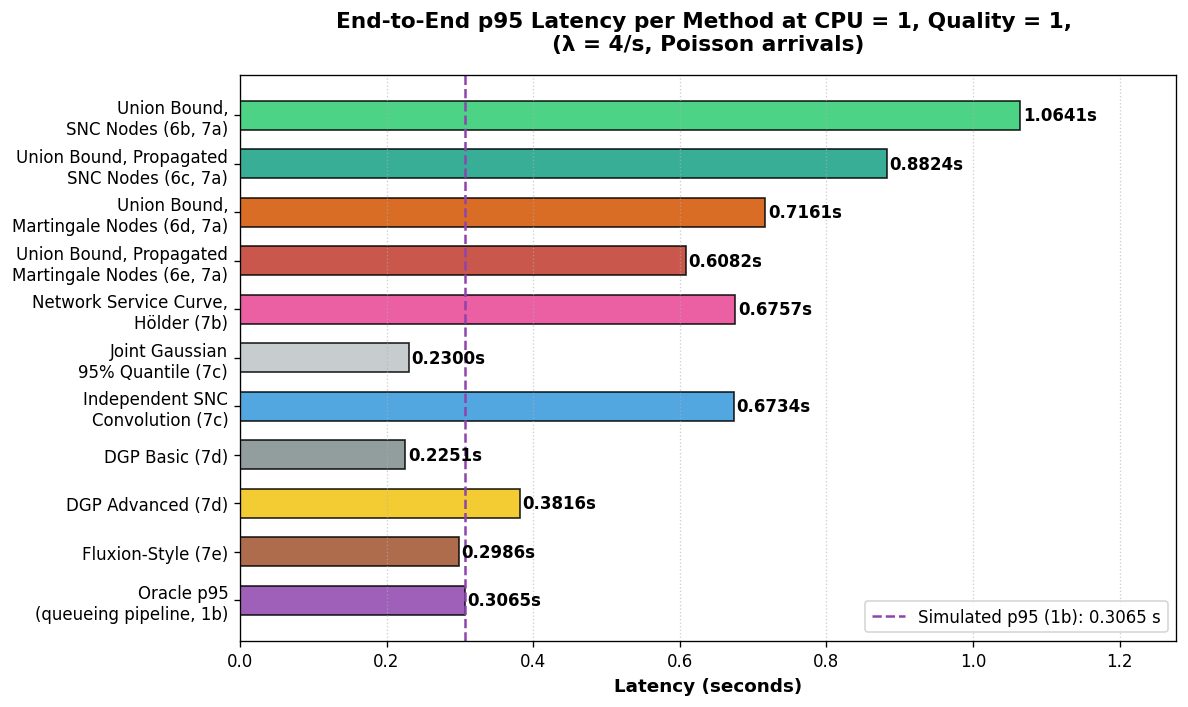

In [21]:
# ------------------------------------------------------------------------------
# E. Visualization: Reference Configuration Bar Chart
# ------------------------------------------------------------------------------
# ordered by subsection (7a, 7b, 7c, 7d, 7e), ground truth last; gray: execution times only (no queue; dark gray: DGP Basic),
# colored: latency bounds, DGP Advanced and Fluxion-style, purple: ground truth
labels = [
    'Union Bound,\nSNC Nodes (6b, 7a)',
    'Union Bound, Propagated\nSNC Nodes (6c, 7a)',
    'Union Bound,\nMartingale Nodes (6d, 7a)',
    'Union Bound, Propagated\nMartingale Nodes (6e, 7a)',
    'Network Service Curve,\nHölder (7b)',
    f'Joint Gaussian\n{p_str}% Quantile (7c)',
    'Independent SNC\nConvolution (7c)',
    'DGP Basic (7d)',
    'DGP Advanced (7d)',
    'Fluxion-Style (7e)',
    f'Oracle p{p_str}\n(queueing pipeline, 1b)'
]
values = [union_snc_bound, propagated_bound, martingale_bound, propagated_martingale_bound, network_bound, joint_gaussian_bound,
          independent_bound, dgp_basic_bound, dgp_advanced_bound, fluxion_bound, oracle_queueing_p_latency]
colors = ['#2ecc71', '#16a085', '#d35400', '#c0392b', '#e84393', '#bdc3c7', '#3498db', '#7f8c8d', '#f1c40f', '#a0522d', '#8e44ad']

plt.figure(figsize=(10, 6), dpi=120)
bars = plt.barh(labels, values, color=colors, edgecolor='black', alpha=0.85, height=0.6)

plt.axvline(
    x=oracle_queueing_p_latency,
    color='#8e44ad',
    linestyle='--',
    linewidth=1.5,
    label=f'Simulated p{p_str} (1b): {oracle_queueing_p_latency:.4f} s'
)

for bar in bars:
    width = bar.get_width()
    plt.text(
        width + 0.004,
        bar.get_y() + bar.get_height()/2,
        f'{width:.4f}s',
        va='center',
        ha='left',
        fontsize=10,
        fontweight='bold'
    )

plt.xlim(0, max(values) * 1.2)
plt.xlabel('Latency (seconds)', fontsize=11, fontweight='bold')
plt.title(
    f'End-to-End p{p_str} Latency per Method at CPU = {x_pipeline_cfg[0, 0]:g}, Quality = {x_pipeline_cfg[0, 1]:g}, '
    f'\n(λ = {arrival_rate:g}/s, {arrival_name} arrivals)',
    fontsize=13,
    fontweight='bold',
    pad=15
)
plt.gca().invert_yaxis()
plt.grid(axis='x', linestyle=':', alpha=0.6)
plt.legend(loc='lower right', frameon=True)
plt.tight_layout()
plt.show()

In [22]:
guaranteed = {"union bound, SNC nodes (6b, 7a)": union_snc_bound, "union bound, propagated SNC nodes (6c, 7a)": propagated_bound,
              "union bound, martingale nodes (6d, 7a)": martingale_bound, "union bound, propagated martingale nodes (6e, 7a)": propagated_martingale_bound,
              "network service curve, Hölder (7b)": network_bound}
truth = oracle_queueing_p_latency
shift = oracle_independent_p_latency - truth
reference_utilization = arrival_rate * max(true_demand(x_pipeline_cfg, s_type)[0] for s_type in service_types)   # of the slowest service
display(Markdown(
    f"**What this shows** ({arrival_name} arrivals, λ = {arrival_rate:g}/s; multiples are of the simulated p{p_str} of {truth:.3f} s, 1b).\n"
    "- **Compositions with a guarantee (7a, 7b):** " + ", ".join(f"{name} {value:.3f} s ({ratio(value / truth)})" for name, value in guaranteed.items())
    + f". The tightest guarantee here: {min(guaranteed, key=guaranteed.get)}. The network service curve (7b) is "
    f"{'tighter' if network_bound < union_snc_bound else 'looser'} than the union bound over the same SNC node moments (6b, 7a).\n"
    f"- **Composition by independence (7c):** the joint Gaussian quantile ({joint_gaussian_bound:.3f} s, "
    f"{ratio(joint_gaussian_bound / truth)}) has no queue and {'falls below' if joint_gaussian_bound < truth else 'lies above'} "
    f"the simulated p{p_str}; the independent SNC convolution ({ratio(independent_bound / truth)}) includes the queue but assumes "
    f"independent nodes. Removing the dependence between the simulated node latencies moves the p{p_str} "
    f"{'down' if shift < 0 else 'up'} by {abs(shift) * 1000:.1f} ms; the paired test on the same items finds "
    + ("that assuming independence significantly underestimates the tail here" if independence_upper[0] < 0 else
       "no significant difference at this single configuration")
    + f" (at {pct(coverage_check['confidence'])} confidence; Section 9 tests it across configurations and depths).\n"
    f"- **Deep GP baselines (7d, no guarantee):** DGP Basic {dgp_basic_bound:.3f} s ({ratio(dgp_basic_bound / truth)}) has no "
    f"queue; DGP Advanced {dgp_advanced_bound:.3f} s ({ratio(dgp_advanced_bound / truth)}) learns the queue from traces of this "
    "workload but has no tail bound.\n"
    f"- **Fluxion-style composition (7e, no guarantee):** {fluxion_bound:.3f} s ({ratio(fluxion_bound / truth)}), a point "
    f"prediction of the p{p_str} learned from traces of this workload; it {'falls below' if fluxion_bound < truth else 'lies above'} "
    f"the simulated p{p_str} here, and nothing in the method decides on which side it falls.\n"
    f"- **One configuration only:** at the reference configuration the slowest service is busy {pct(reference_utilization)} of "
    "the time. A single configuration cannot show coverage: a method without a guarantee can be above the ground truth "
    "here and below it elsewhere. Section 9 measures coverage over many held-out configurations."))

**What this shows** (Poisson arrivals, λ = 4/s; multiples are of the simulated p95 of 0.307 s, 1b).
- **Compositions with a guarantee (7a, 7b):** union bound, SNC nodes (6b, 7a) 1.064 s (3.47×), union bound, propagated SNC nodes (6c, 7a) 0.882 s (2.88×), union bound, martingale nodes (6d, 7a) 0.716 s (2.34×), union bound, propagated martingale nodes (6e, 7a) 0.608 s (1.98×), network service curve, Hölder (7b) 0.676 s (2.20×). The tightest guarantee here: union bound, propagated martingale nodes (6e, 7a). The network service curve (7b) is tighter than the union bound over the same SNC node moments (6b, 7a).
- **Composition by independence (7c):** the joint Gaussian quantile (0.230 s, 0.75×) has no queue and falls below the simulated p95; the independent SNC convolution (2.20×) includes the queue but assumes independent nodes. Removing the dependence between the simulated node latencies moves the p95 down by 0.4 ms; the paired test on the same items finds that assuming independence significantly underestimates the tail here (at 95% confidence; Section 9 tests it across configurations and depths).
- **Deep GP baselines (7d, no guarantee):** DGP Basic 0.225 s (0.73×) has no queue; DGP Advanced 0.382 s (1.24×) learns the queue from traces of this workload but has no tail bound.
- **Fluxion-style composition (7e, no guarantee):** 0.299 s (0.97×), a point prediction of the p95 learned from traces of this workload; it falls below the simulated p95 here, and nothing in the method decides on which side it falls.
- **One configuration only:** at the reference configuration the slowest service is busy 32% of the time. A single configuration cannot show coverage: a method without a guarantee can be above the ground truth here and below it elsewhere. Section 9 measures coverage over many held-out configurations.

## 8. Design Space Sensitivity & Sweep Analysis

To check that the bounds hold across different allocations, we sweep CPU availability and quality over the training
range while tracking bound tightness and pessimism. The bound is the union bound over SNC node bounds (Sections 6b, 7a)
and the oracle is the simulated queueing pipeline; tightness is the ratio bound ÷ measured p95, and coverage is checked as in 6f. The other compositions with a
guarantee (the union bound over the propagated SNC, martingale and propagated martingale node bounds, 6c–6e, and the
network service curve, 7b) are compared in Sections 7f and 9. The simulation is vectorized over
the grid.

Union bound, SNC nodes: coverage over the grid 100.0% of 1225 configurations; tightness median 3.58x (range 3.03x – 4.83x)


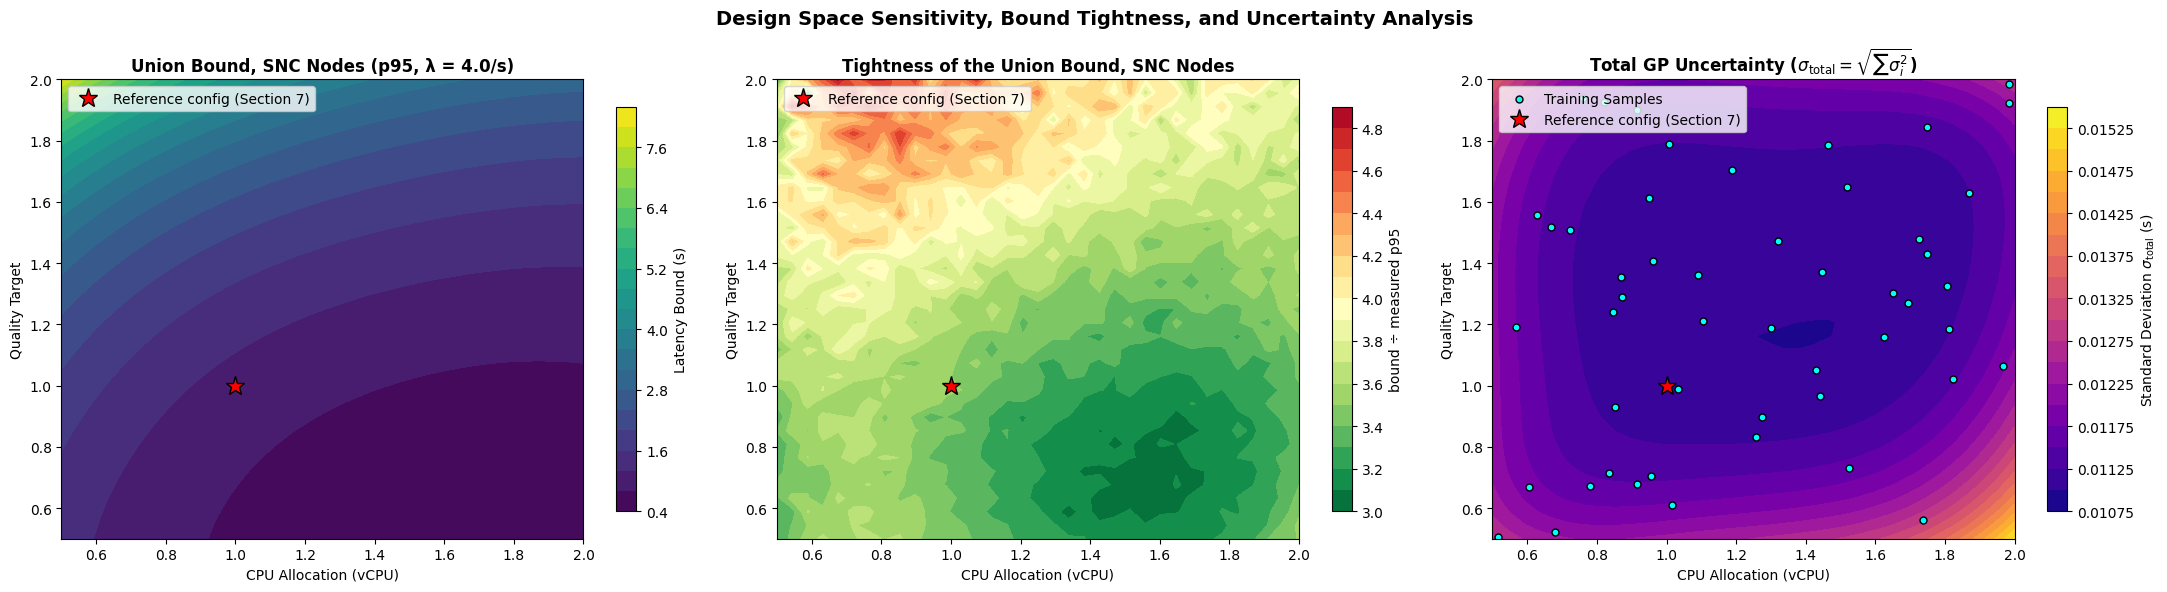

In [23]:
# ------------------------------------------------------------------------------
# A. Build 2D Meshgrid & Storage Matrices
# ------------------------------------------------------------------------------
n_sweep = 35  # grid points per axis; the grid has n_sweep x n_sweep evaluation points
cpu_axis = np.linspace(0.5, 2.0, n_sweep)
quality_axis = np.linspace(0.5, 2.0, n_sweep)

CPU_grid, QUALITY_grid = np.meshgrid(cpu_axis, quality_axis)
PARALLELISM_grid = np.full_like(CPU_grid, 2.0)

# Flatten grid for batched GP predictions
X_2d_sweep = np.column_stack([
    CPU_grid.ravel(),
    QUALITY_grid.ravel(),
    PARALLELISM_grid.ravel()
])

# ------------------------------------------------------------------------------
# B. Evaluate the Union Bound over SNC Node Bounds, Oracle Ground Truth & Uncertainty (vectorized)
# ------------------------------------------------------------------------------
sweep_beliefs = [execution_time_belief(gp_models[s_name], X_2d_sweep, confidence) for s_name in service_names]
union_snc_surface = sum(snc_latency_bound(*belief, epsilon=alpha / n_nodes, **workload) for belief in sweep_beliefs)

std_total_surface = np.sqrt(sum(gp_models[s_name].predict(X_2d_sweep, return_std=True)[1] ** 2 for s_name in service_names))

rng_sweep = np.random.default_rng(42)
_, sweep_latencies = simulate_pipeline(X_2d_sweep, service_types, [noise_levels[s] for s in service_names],
                                       n_sim_items, item_correlation, rng_sweep, workload)
oracle_surface, oracle_low_surface = quantile_with_lower_bound(sweep_latencies, 1 - alpha, **coverage_check)
ratio_surface = union_snc_surface / oracle_surface

print(f"Union bound, SNC nodes: coverage over the grid {np.mean(union_snc_surface >= oracle_low_surface):.1%} of {len(X_2d_sweep)} configurations; "
      f"tightness median {np.median(ratio_surface):.2f}x (range {ratio_surface.min():.2f}x – {ratio_surface.max():.2f}x)")

# Reshape flattened results back to 2D matrix shape
Union_SNC_matrix = union_snc_surface.reshape(n_sweep, n_sweep)
Ratio_matrix = ratio_surface.reshape(n_sweep, n_sweep)
Std_Total_matrix = std_total_surface.reshape(n_sweep, n_sweep)

# ------------------------------------------------------------------------------
# C. Side-by-Side Unified Plotting (1 Row x 3 Columns - Clean 2D Grid)
# ------------------------------------------------------------------------------
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(22, 6), dpi=100)

# reference configuration of Section 7
reference_cpu = x_pipeline_cfg[0, 0]
reference_quality = x_pipeline_cfg[0, 1]
reference_label = 'Reference config (Section 7)'

# Subplot 1: Absolute Latency Bound Surface (2D Contour)
c1 = ax1.contourf(CPU_grid, QUALITY_grid, Union_SNC_matrix, levels=20, cmap='viridis')
fig.colorbar(c1, ax=ax1, shrink=0.88, label='Latency Bound (s)')
ax1.plot(reference_cpu, reference_quality, 'r*', markersize=14, markeredgecolor='black', label=reference_label)
ax1.set_title(f'Union Bound, SNC Nodes (p{p_str}, λ = {arrival_rate}/s)', fontsize=12, fontweight='bold')
ax1.set_xlabel('CPU Allocation (vCPU)', fontsize=10)
ax1.set_ylabel('Quality Target', fontsize=10)
ax1.legend(loc='upper left', frameon=True)

# Subplot 2: tightness ratio; the dashed line marks ratio 1 (violation below it)
c2 = ax2.contourf(CPU_grid, QUALITY_grid, Ratio_matrix, levels=20, cmap='RdYlGn_r')
fig.colorbar(c2, ax=ax2, shrink=0.88, label=f'bound ÷ measured p{p_str}')
ax2.plot(reference_cpu, reference_quality, 'r*', markersize=14, markeredgecolor='black', label=reference_label)
if Ratio_matrix.min() < 1.0:
    contour_one = ax2.contour(CPU_grid, QUALITY_grid, Ratio_matrix, levels=[1.0], colors='black', linewidths=2.0, linestyles='--')
    ax2.clabel(contour_one, inline=True, fmt='violation', fontsize=9)
ax2.set_title('Tightness of the Union Bound, SNC Nodes', fontsize=12, fontweight='bold')
ax2.set_xlabel('CPU Allocation (vCPU)', fontsize=10)
ax2.set_ylabel('Quality Target', fontsize=10)
ax2.legend(loc='upper left', frameon=True)

# Subplot 3: Total GP Uncertainty Surface (2D Contour - Perfectly Aligned)
c3 = ax3.contourf(CPU_grid, QUALITY_grid, Std_Total_matrix, levels=20, cmap='plasma')
fig.colorbar(c3, ax=ax3, shrink=0.88, label=r'Standard Deviation $\sigma_{\mathrm{total}}$ (s)')

# Scatter training data points
ax3.scatter(X_train[:, 0], X_train[:, 1], color='cyan', edgecolors='black', s=25, label='Training Samples')

# Plot the reference configuration
ax3.plot(reference_cpu, reference_quality, 'r*', markersize=14, markeredgecolor='black', label=reference_label)

ax3.set_title(r'Total GP Uncertainty ($\sigma_{\mathrm{total}} = \sqrt{\sum \sigma_i^2}$)', fontsize=12, fontweight='bold')
ax3.set_xlabel('CPU Allocation (vCPU)', fontsize=10)
ax3.set_ylabel('Quality Target', fontsize=10)
ax3.legend(loc='upper left', frameon=True)

plt.suptitle("Design Space Sensitivity, Bound Tightness, and Uncertainty Analysis", fontsize=14, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()

In [24]:
from scipy.stats import spearmanr

loosest, tightest = np.argmax(ratio_surface), np.argmin(ratio_surface)
rank_correlation = spearmanr(std_total_surface, ratio_surface).statistic
at = lambda index: f"CPU = {X_2d_sweep[index, 0]:.2f}, quality = {X_2d_sweep[index, 1]:.2f}"
display(Markdown(
    f"**What this shows** ({arrival_name} arrivals, λ = {arrival_rate:g}/s). Left: the union bound over SNC node bounds, over CPU and quality at the "
    f"parallelism of the reference configuration. Middle: that bound divided by the simulated p{p_str}; values below 1 would be violations and are "
    "outlined by a dashed line if there are any. Right: the total GP standard deviation and the training configurations.\n"
    f"- **Coverage:** the bound covers {pct(np.mean(union_snc_surface >= oracle_low_surface))} of the {len(X_2d_sweep)} grid configurations.\n"
    f"- **Tightness** ranges from {ratio(ratio_surface.min())} ({at(tightest)}) to {ratio(ratio_surface.max())} "
    f"({at(loosest)}), median {ratio(np.median(ratio_surface))}.\n"
    f"- **Uncertainty and tightness:** the Spearman rank correlation between the GP standard deviation and the tightness "
    f"is {rank_correlation:+.2f}: "
    + ("tightness and GP uncertainty are barely related." if abs(rank_correlation) < 0.3 else
       f"the bound is {'looser' if rank_correlation > 0 else 'tighter'} where the GP is less certain.")))

**What this shows** (Poisson arrivals, λ = 4/s). Left: the union bound over SNC node bounds, over CPU and quality at the parallelism of the reference configuration. Middle: that bound divided by the simulated p95; values below 1 would be violations and are outlined by a dashed line if there are any. Right: the total GP standard deviation and the training configurations.
- **Coverage:** the bound covers 100% of the 1225 grid configurations.
- **Tightness** ranges from 3.03× (CPU = 1.60, quality = 0.68) to 4.83× (CPU = 0.54, quality = 1.91), median 3.58×.
- **Uncertainty and tightness:** the Spearman rank correlation between the GP standard deviation and the tightness is -0.06: tightness and GP uncertainty are barely related.

## 9. Composition vs. Depth (RQ2)

Chains of $K$ services, cycling through $s_1, s_2, s_3$ (every node has its own queue), at random held-out
configurations shared by all nodes (the global-quality assumption). For every depth we compare the compositions with a guarantee (the union bound over each of the four
node bounds, 7a: SNC, 6b; propagated SNC, 6c; martingale, 6d; propagated martingale, 6e; and the network service curve,
7b) with the composition by independence (independent SNC convolution, 7c), the two Deep GP baselines (7d), the Fluxion-style composition (7e), and two oracles that use the *measured*
node latencies instead of the node bounds: one composes them with the union bound (this isolates what the union bound
itself costs), the other combines them as if they were independent (this shows directly whether independence is a safe
assumption, without any model error; it is not a bound, so it is tested in pairs on the same simulated items
instead of by coverage). Coverage is checked as in 6f.

**The figure** has three panels, each over the chain depth $K$ (number of services, logarithmic axis).
- *Left, coverage:* the share of the held-out configurations that a composition does not miss. The dashed line is the
  confidence level $c$ (6b), the target of the compositions with a guarantee. The baselines without a guarantee (7c–7e)
  are not built to reach it; their line shows how often they fall below the measured quantile.
- *Middle, tightness of the compositions built from node bounds:* the median over the configurations of bound ÷ measured
  quantile. A value of 1 would be exact; larger is looser. Look at how fast each line grows with $K$.
- *Right, tightness of the methods that predict or measure the quantile directly* (the Deep GP baselines, the
  Fluxion-style composition and the two oracles), on its own scale, because all of them lie close to 1. A value below 1
  means that the median prediction is below the measured quantile.

The conclusion below the figure is rendered from the same results.

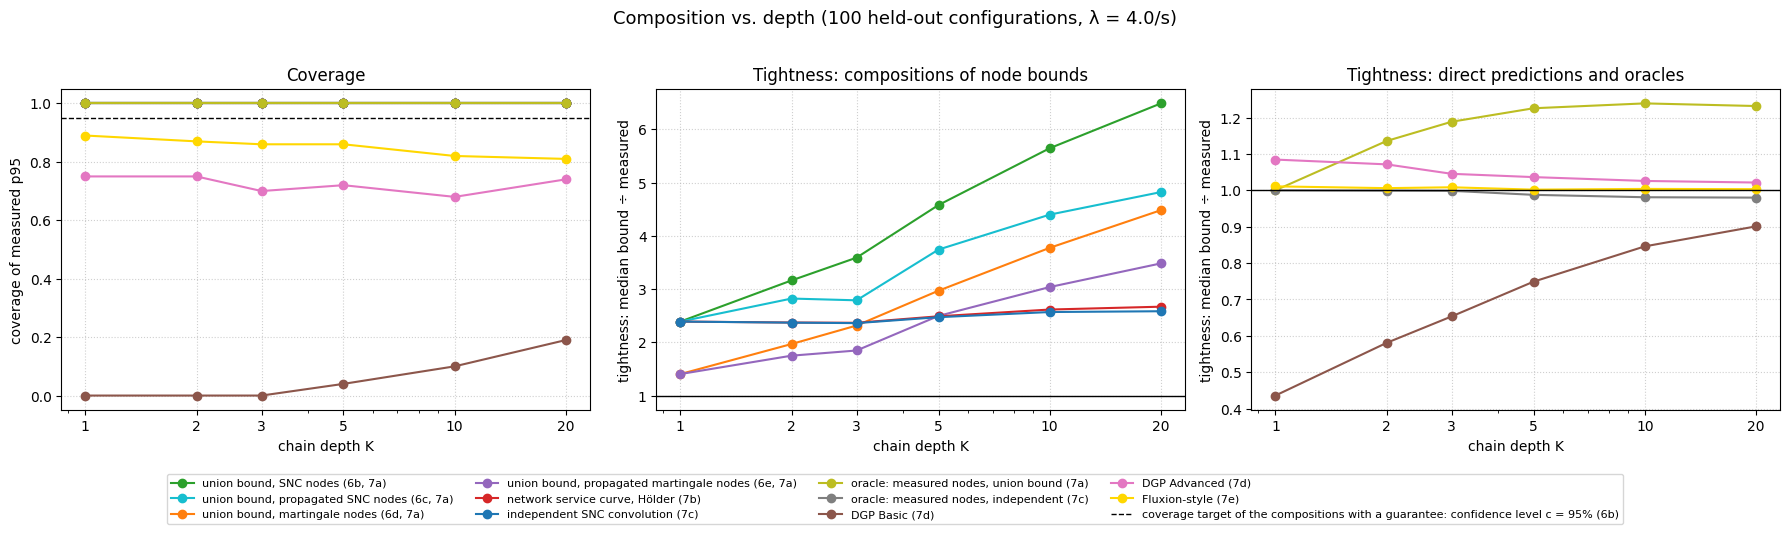

In [25]:
n_cfg_depth = 100
rng_depth = np.random.default_rng(11)

X_cfg_depth = np.column_stack([
    rng_depth.uniform(0.5, 2.0, n_cfg_depth),
    rng_depth.uniform(0.5, 2.0, n_cfg_depth),
    rng_depth.uniform(1.0, 4.0, n_cfg_depth)
])
beliefs_by_service = {s_name: execution_time_belief(gp_models[s_name], X_cfg_depth, confidence) for s_name in service_names}

# Depth-independent work, done once: the propagated moments of the longest chain (every shorter chain is a prefix of it,
# and the moments do not depend on epsilon), and the martingale bounds of every service at every epsilon = alpha / depth.
longest_path = [service_names[k % 3] for k in range(max(depths))]
lower_mean_by_service = {s_name: execution_time_belief(gp_models[s_name], X_cfg_depth, 1 - confidence)[0] for s_name in service_names}   # optimistic means (6c, 6e)
propagated_moments = propagated_node_moments([beliefs_by_service[s] for s in longest_path], **workload,
                                             path_lower_means=[lower_mean_by_service[s] for s in longest_path])
martingale_by_service = {s: martingale_node_bound(*beliefs_by_service[s], epsilon=[alpha / d for d in depths], **workload) for s in service_names}
# 6e depends on the node and the one before it: one bound per pair on the longest chain, for every epsilon = alpha / depth
propagated_martingale_by_pair = {(s, p): martingale_propagated_node_bound(*beliefs_by_service[s], None if p is None else lower_mean_by_service[p],
                                                                          None if p is None else beliefs_by_service[p][1],
                                                                          epsilon=[alpha / d for d in depths], **workload)
                                 for s, p in set(zip(longest_path, [None] + longest_path[:-1]))}

rng_independence = np.random.default_rng(5)   # own random generator: the paired test leaves every simulation unchanged
independence_by_depth = {}                    # per depth: relative change of the p95 and upper edge (paired test, 7c)
depth_rows = []
for depth in depths:
    path = [service_names[k % 3] for k in range(depth)]
    node_latencies, latencies = simulate_pipeline(X_cfg_depth, [service_types[k % 3] for k in range(depth)],
                                                  [noise_levels[s] for s in path], n_sim_items, item_correlation, rng_depth, workload)
    measured, measured_low = quantile_with_lower_bound(latencies, 1 - alpha, **coverage_check)
    shuffled = independent_node_latencies(node_latencies, rng_depth)
    independence_by_depth[depth] = paired_independence_effect(node_latencies, 1 - alpha, rng_independence, **coverage_check)
    compositions = {
        "union bound, SNC nodes (6b, 7a)": sum(snc_latency_bound(*beliefs_by_service[s], epsilon=alpha / depth, **workload) for s in path),
        "union bound, propagated SNC nodes (6c, 7a)": propagated_node_bounds([beliefs_by_service[s] for s in path], epsilon=alpha / depth, moments=propagated_moments, **workload).sum(axis=0),
        "union bound, martingale nodes (6d, 7a)": sum(martingale_by_service[s][depths.index(depth)] for s in path),
        "union bound, propagated martingale nodes (6e, 7a)": sum(propagated_martingale_by_pair[(s, p)][depths.index(depth)] for s, p in zip(path, [None] + path[:-1])),
        "network service curve, Hölder (7b)": network_service_bound([beliefs_by_service[s] for s in path], epsilon=alpha, **workload),
        "oracle: measured nodes, union bound (7a)": union_bound_oracle(node_latencies, alpha),
        "independent SNC convolution (7c)": independent_snc_convolution([beliefs_by_service[s] for s in path], alpha, **workload),
        "oracle: measured nodes, independent (7c)": quantile_per_config(shuffled),
        "DGP Basic (7d)": dgp_basic.latency_bound(X_cfg_depth, alpha, depth),
        "DGP Advanced (7d)": dgp_advanced.latency_bound(X_cfg_depth, alpha, depth),
        "Fluxion-style (7e)": fluxion.latency_bound(X_cfg_depth, alpha, depth),
    }
    for name, bound in compositions.items():
        depth_rows.append({"depth": depth, "composition": name, "coverage": np.mean(bound >= measured_low), "tightness": np.median(bound / measured)})

# Left: coverage. Middle: tightness of the compositions built from node bounds. Right: tightness of the methods that predict
# or measure the quantile directly; they all lie close to 1 and would be indistinguishable on the scale of the middle panel.
guaranteed_names = ['union bound, SNC nodes (6b, 7a)', 'union bound, propagated SNC nodes (6c, 7a)', 'union bound, martingale nodes (6d, 7a)',
                    'union bound, propagated martingale nodes (6e, 7a)', 'network service curve, Hölder (7b)']
direct_names = ['oracle: measured nodes, union bound (7a)', 'oracle: measured nodes, independent (7c)', 'DGP Basic (7d)', 'DGP Advanced (7d)', 'Fluxion-style (7e)']
composition_colors = dict(zip(guaranteed_names + ['independent SNC convolution (7c)'] + direct_names,
                              ['tab:green', 'tab:cyan', 'tab:orange', 'tab:purple', 'tab:red', 'tab:blue', 'tab:olive', 'tab:gray', 'tab:brown', 'tab:pink', 'gold']))
fig, (ax_cov, ax_bounds, ax_direct) = plt.subplots(1, 3, figsize=(18, 4.5))
handles = {}
for name, color in composition_colors.items():
    rows = [row for row in depth_rows if row["composition"] == name]
    if not name.startswith("oracle: measured nodes, independent"):   # not a bound: tested in pairs instead (conclusion below)
        ax_cov.plot(depths, [row["coverage"] for row in rows], "o-", color=color)
    handles[name], = (ax_direct if name in direct_names else ax_bounds).plot(depths, [row["tightness"] for row in rows], "o-", color=color)
handles[f"coverage target of the compositions with a guarantee: confidence level c = {confidence:.0%} (6b)"] = ax_cov.axhline(confidence, color="black", linestyle="--", linewidth=1)
ax_cov.set_ylabel(f"coverage of measured p{p_str}")
ax_cov.set_title("Coverage")
ax_bounds.set_title("Tightness: compositions of node bounds")
ax_direct.set_title("Tightness: direct predictions and oracles")
for ax in (ax_bounds, ax_direct):
    ax.axhline(1.0, color="black", linewidth=1)
    ax.set_ylabel("tightness: median bound ÷ measured")
for ax in (ax_cov, ax_bounds, ax_direct):
    ax.set_xscale("log")
    ax.set_xticks(depths, [str(d) for d in depths])
    ax.set_xlabel("chain depth K")
    ax.grid(True, linestyle=":", alpha=0.6)
fig.legend(handles.values(), handles.keys(), loc="upper center", bbox_to_anchor=(0.5, 0.0), ncol=4, fontsize=8)
plt.suptitle(f"Composition vs. depth ({n_cfg_depth} held-out configurations, λ = {arrival_rate}/s)", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

In [26]:
by = {(row["depth"], row["composition"]): row for row in depth_rows}
shallow, deep = min(depths), max(depths)
describe = lambda name: (f"{name}: coverage {pct(by[(shallow, name)]['coverage'])} at K = {shallow} and {pct(by[(deep, name)]['coverage'])} at K = {deep}, "
                         f"tightness {ratio(by[(shallow, name)]['tightness'])} and {ratio(by[(deep, name)]['tightness'])}")
lowest_guaranteed = min(by[(depth, name)]["coverage"] for depth in depths for name in guaranteed_names)
tightest_deep = min(guaranteed_names, key=lambda name: by[(deep, name)]["tightness"])
union_oracle = "oracle: measured nodes, union bound (7a)"
# Paired test of independence (7c), for chains of at least two services (a single service has no dependence to remove):
# median relative change of the quantile and share of configurations where independence significantly underestimates it
chain_depths = [depth for depth in depths if depth > 1]
independence_change = [np.median(independence_by_depth[depth][0]) for depth in chain_depths]
independence_significant = [np.mean(independence_by_depth[depth][1] < 0) for depth in chain_depths]
signed_pct = lambda value: f"{value:+.1%}"
display(Markdown(
    f"**What this shows** ({arrival_name} arrivals, λ = {arrival_rate:g}/s; {n_cfg_depth} held-out configurations per depth; "
    f"chains of K = {shallow} to {deep} services; tightness is the median of bound ÷ measured p{p_str}).\n"
    f"- **Compositions with a guarantee (7a, 7b):** the lowest coverage of any of them at any depth is {pct(lowest_guaranteed)} "
    f"(target: {pct(confidence)}). At K = {deep} the tightest is the {tightest_deep} ({ratio(by[(deep, tightest_deep)]['tightness'])}).\n"
    + "".join(f"  - {describe(name)}\n" for name in guaranteed_names)
    + f"- **What the union bound itself costs:** composing the *measured* node quantiles with the union bound gives tightness "
    f"{ratio(by[(shallow, union_oracle)]['tightness'])} at K = {shallow} and {ratio(by[(deep, union_oracle)]['tightness'])} at K = {deep}. "
    "The distance between this oracle and a union-bound composition (7a) is the looseness of the node bounds, not of the union bound.\n"
    f"- **Composition by independence (7c, no guarantee):** {describe('independent SNC convolution (7c)')}. In the paired test on "
    f"the same simulated items, removing the dependence between the nodes changes the measured p{p_str} by a median of "
    f"{span(independence_change, signed_pct)} over the depths K = {chain_depths[0]} to {chain_depths[-1]}, and independence "
    f"significantly underestimates the p{p_str} (at {pct(coverage_check['confidence'])} confidence) for "
    f"{span(independence_significant, pct)} of the configurations.\n"
    "- **Learned compositions (7d, 7e, no guarantee):**\n"
    + "".join(f"  - {describe(name)}\n" for name in ("DGP Basic (7d)", "DGP Advanced (7d)", "Fluxion-style (7e)"))
    + "  A tightness close to 1× together with a coverage below the target means that the prediction is accurate for the median "
    f"configuration and still lies below the measured p{p_str} for the remaining share of the configurations: accuracy is not a guarantee."))

**What this shows** (Poisson arrivals, λ = 4/s; 100 held-out configurations per depth; chains of K = 1 to 20 services; tightness is the median of bound ÷ measured p95).
- **Compositions with a guarantee (7a, 7b):** the lowest coverage of any of them at any depth is 100% (target: 95%). At K = 20 the tightest is the network service curve, Hölder (7b) (2.67×).
  - union bound, SNC nodes (6b, 7a): coverage 100% at K = 1 and 100% at K = 20, tightness 2.39× and 6.49×
  - union bound, propagated SNC nodes (6c, 7a): coverage 100% at K = 1 and 100% at K = 20, tightness 2.39× and 4.82×
  - union bound, martingale nodes (6d, 7a): coverage 100% at K = 1 and 100% at K = 20, tightness 1.40× and 4.48×
  - union bound, propagated martingale nodes (6e, 7a): coverage 100% at K = 1 and 100% at K = 20, tightness 1.40× and 3.48×
  - network service curve, Hölder (7b): coverage 100% at K = 1 and 100% at K = 20, tightness 2.39× and 2.67×
- **What the union bound itself costs:** composing the *measured* node quantiles with the union bound gives tightness 1.00× at K = 1 and 1.23× at K = 20. The distance between this oracle and a union-bound composition (7a) is the looseness of the node bounds, not of the union bound.
- **Composition by independence (7c, no guarantee):** independent SNC convolution (7c): coverage 100% at K = 1 and 100% at K = 20, tightness 2.39× and 2.58×. In the paired test on the same simulated items, removing the dependence between the nodes changes the measured p95 by a median of between -2.0% and -0.1% over the depths K = 2 to 20, and independence significantly underestimates the p95 (at 95% confidence) for between 25% and 100% of the configurations.
- **Learned compositions (7d, 7e, no guarantee):**
  - DGP Basic (7d): coverage 0% at K = 1 and 19% at K = 20, tightness 0.44× and 0.90×
  - DGP Advanced (7d): coverage 75% at K = 1 and 74% at K = 20, tightness 1.08× and 1.02×
  - Fluxion-style (7e): coverage 89% at K = 1 and 81% at K = 20, tightness 1.01× and 1.00×
  A tightness close to 1× together with a coverage below the target means that the prediction is accurate for the median configuration and still lies below the measured p95 for the remaining share of the configurations: accuracy is not a guarantee.